# Synthetic Probe Test — Per-Judge, Per-Train-Dataset Evaluation

For each `(judge_model, train_dataset)` combination, evaluate the trained probe
across four test settings and produce publication-ready figures and a summary table.

**Four test settings** (color = test dataset; linestyle = real vs. synthetic):
1. **Syn {train\_dataset} (within)** — synthetic held-out test split, same domain as training
2. **Syn {other\_dataset} (cross)** — synthetic held-out test split, cross-domain
3. **Real {train\_dataset} (within)** — real extraction outputs, same domain as training
4. **Real {other\_dataset} (cross)** — real extraction outputs, cross-domain

**Per-combination outputs**:
- **Calibration curves**: probe (solid) vs. NTP baseline (faint dotted), one line per test setting
- **Threshold sweep** (2 × 2 grid): recovery vs. hallucination rate as decision threshold varies
- **Summary table**: one row per (test setting × method) at threshold = 0.5

**Frontier judge baselines** evaluated on synthetic test data are independent of the
probe analysis and appear in their own section.

**Label definition** (`LABEL_MODE = 'union'`): a real extraction is positive if it matches
a ground-truth row **or** the majority-vote frontier judge says valid.

**Prerequisites**: Run `synthetic_probe_analysis.ipynb` for each `(dataset, judge_model)`
combination before running this notebook.

In [1]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import precision_recall_curve

from analysis.loaders import (
    load_activations, load_layer_outputs, load_combined_judgements,
    load_extraction, load_ground_truth, load_trained_probe,
    cached_match, load_synthetic_activations, load_synthetic_layer_outputs, 
    load_synthetic_responses,
)
from scholarlm.utils.calibration import reliability_diagram_data, rescale_probabilities_em
from scholarlm.utils.unit_conversion import apply_unit_conversion
from experiments.run_extraction import load_dataset_config
import paths

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.title_fontsize": 9,
    "axes.linewidth": 0.6,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "legend.frameon": False,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.format": "pdf", "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# blue: 7, orange: 1, red: 0, green: 4
palette = sns.color_palette("husl", 10)

FIGURES_DIR = "../figures/synthetic_probe/"
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

In [2]:
# ── Parameters ───────────────────────────────────────────────────────────────
DATASETS = ['pond', 'nfix']
EXTRACTION_MODEL = 'gemma-3-27b'
JUDGE_MODELS = ['llama-3.1-8b', 'mistral-7b', 'qwen-2.5-7b']


# Extraction date per test dataset
EXTRACTION_DATES = {
    'pond': '2026_05_05',
    'nfix': '2026_05_06',
}

# Judge date for synthetic test activations: {dataset: {judge_model: date_str | None}}
# None → auto-detect latest
JUDGE_DATES_SYN = {
    'pond': {
        'llama-3.1-8b': '2026_05_04',
        'mistral-7b': '2026_05_04',
        'qwen-2.5-7b': '2026_05_04',
    },
    'nfix': {
        'llama-3.1-8b': '2026_05_04',
        'mistral-7b': '2026_05_04',
        'qwen-2.5-7b': '2026_05_04',
    },
}

# Judge date for real activations: {test_dataset: {judge_model: date_str | None}}
# None → auto-detect latest
JUDGE_DATES_REAL = {
    'pond': {
        'llama-3.1-8b': '2026_05_06',
        'mistral-7b': '2026_05_06',
        'qwen-2.5-7b': '2026_05_06',
    },
    'nfix': {
        'llama-3.1-8b': '2026_05_05',
        'mistral-7b': '2026_05_05',
        'qwen-2.5-7b': '2026_05_05',
    },
}

THRESHOLD_SWEEP = np.linspace(0.0, 0.95, 20)  # thresholds for operating-curve plot
EDGE_THRESHOLD  = 1 / 3  # minimum fuzzy weight to count as a match

# Visual style
JUDGE_COLORS = {
    'llama-3.1-8b': '#3984e0',
    'mistral-7b':   '#2eb07b',
    'qwen-2.5-7b':   '#d946a6',
}

## Load Trained Probes

In [3]:
PROBE_TYPE = "head"
probe_cache = {}
for ds in DATASETS:
    probe_cache[ds] = {}
    for jm in JUDGE_MODELS:
        probe_cache[ds][jm] = load_trained_probe(ds, jm, ptype = PROBE_TYPE)
        if PROBE_TYPE == "layer":
            top = probe_cache[ds][jm]['top_layer']
            print(f'  {ds} / {jm}: top layer={top}  pi_tr={probe_cache[ds][jm]["train_prevalence"]:.3f}')
        else:
            top = probe_cache[ds][jm]['top_k_heads']
            print(f'  {ds} / {jm}: top heads={top}  pi_tr={probe_cache[ds][jm]["train_prevalence"]:.3f}')

  pond / llama-3.1-8b: top heads=[(np.int64(30), np.int64(19)), (np.int64(31), np.int64(12)), (np.int64(31), np.int64(14)), (np.int64(18), np.int64(26)), (np.int64(26), np.int64(22)), (np.int64(15), np.int64(0)), (np.int64(19), np.int64(7)), (np.int64(16), np.int64(17)), (np.int64(31), np.int64(15)), (np.int64(31), np.int64(31))]  pi_tr=0.333
  pond / mistral-7b: top heads=[(np.int64(18), np.int64(26)), (np.int64(26), np.int64(16)), (np.int64(30), np.int64(18)), (np.int64(31), np.int64(17)), (np.int64(20), np.int64(30)), (np.int64(18), np.int64(11)), (np.int64(17), np.int64(24)), (np.int64(16), np.int64(18)), (np.int64(14), np.int64(26)), (np.int64(25), np.int64(14))]  pi_tr=0.333
  pond / qwen-2.5-7b: top heads=[(np.int64(25), np.int64(19)), (np.int64(27), np.int64(9)), (np.int64(27), np.int64(24)), (np.int64(27), np.int64(22)), (np.int64(27), np.int64(8)), (np.int64(27), np.int64(6)), (np.int64(27), np.int64(19)), (np.int64(27), np.int64(7)), (np.int64(27), np.int64(13)), (np.int64(2

## Analysis Helpers

In [4]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import brier_score_loss


def _probe_metrics(probs, y_true, threshold=0.5):
    """Compute metrics at a fixed threshold. Returns dict."""
    probs   = np.asarray(probs)
    y_true  = np.asarray(y_true, dtype=bool)
    preds   = probs > threshold
    tp  = int(( preds &  y_true).sum())
    tn  = int((~preds & ~y_true).sum())
    fp  = int(( preds & ~y_true).sum())
    fn  = int((~preds &  y_true).sum())
    n   = len(y_true)
    acc   = (tp + tn) / n
    prec  = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec   = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float('nan')
    auroc = roc_auc_score(y_true, probs) if y_true.sum() > 0 and (~y_true).sum() > 0 else float('nan')
    ece   = reliability_diagram_data(probs, y_true)['ece']
    bs    = float(brier_score_loss(y_true, probs))
    p_pos = float(y_true.mean())
    bss   = 1.0 - bs / (p_pos * (1 - p_pos)) if p_pos not in (0.0, 1.0) else float('nan')
    return dict(acc=acc, prec=prec, rec=rec, f1=f1, auroc=auroc,
                ece=ece, bs=bs, bss=bss, n=n)


def compute_rates(probs, threshold, real_test_labels, test_edges, n_gt):
    """Recovery rate and hallucination rate at a given threshold.

    At threshold t:
      accepted      = probs > t (accepted extractions)
      recovery      = fraction of GT rows matched by at least one accepted extraction
      hallucination = fraction of accepted extractions that are invalid
                      (not GT-matched and not judged valid by frontier judge)

    Parameters
    ----------
    probs            : 1-D array aligned with the test set
    threshold        : float
    real_test_labels : bool array aligned with the test set (union labels)
    test_edges       : list of (gt_idx, test_pos) pairs (pre-filtered to test set)
    n_gt             : total number of GT rows
    """
    accepted = np.asarray(probs) > threshold
    n_accepted = accepted.sum()
    if n_accepted == 0:
        return float('nan'), float('nan')
    gt_covered = np.zeros(n_gt, dtype=bool)
    for gt_idx, test_pos in test_edges:
        if accepted[test_pos]:
            gt_covered[gt_idx] = True
    recovery      = float(gt_covered.mean())
    hallucination = float(1 - real_test_labels[accepted].mean())
    return recovery, hallucination


def compute_rates_syn(probs, threshold, labels):
    """Recovery (recall on positives) and hallucination (FP rate among accepted) at threshold.

    Simpler than compute_rates: labels are direct binary labels, no GT matching needed.
    """
    probs  = np.asarray(probs)
    labels = np.asarray(labels, dtype=bool)
    accepted   = probs > threshold
    n_accepted = int(accepted.sum())
    if n_accepted == 0:
        return float('nan'), float('nan')
    n_pos = int(labels.sum())
    recovery      = float((accepted & labels).sum() / n_pos) if n_pos > 0 else float('nan')
    hallucination = float((accepted & ~labels).sum() / n_accepted)
    return recovery, hallucination

## Matching Configuration

In [5]:
_SUPER_MAP  = str.maketrans('⁰¹²³⁴⁵⁶⁷⁸⁹⁻⁺', '0123456789-+')
_SUB_MAP    = str.maketrans('₀₁₂₃₄₅₆₇₈₉₋₊', '0123456789-+')
_SCRIPT_MAP = {**_SUPER_MAP, **_SUB_MAP}

_LATEX_RE    = re.compile(r'[\^_]\{([^}]*)\}|[\^_]([+-]?\d+)')
_COMPOUND_RE = re.compile(r'(\w+)[\s\-]([A-Z][a-zA-Z0-9]*)')


def nfix_clean_unit(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = s.translate(_SCRIPT_MAP)
    s = _LATEX_RE.sub(lambda m: m.group(1) if m.group(1) is not None else m.group(2), s)
    s = s.replace('µ', 'u').replace('μ', 'u')
    s = _COMPOUND_RE.sub(r'\1-\2', s)
    s = re.sub(r'\byr\b', 'y', s)
    s = s.lower()
    s = re.sub(r'\bday\b', 'd', s)
    s = re.sub(r'\bhr\b',  'h', s)
    return s


def get_matching_config(dataset):
    if dataset == 'pond':
        strict = {'document_id': 'document_id', 'attribute': 'attribute',
                  'value': 'converted_value', 'units': 'units'}
        fuzzy  = {'name': 'name', 'location': 'location', 'ecosystem': 'ecosystem'}
    elif dataset == 'nfix':
        strict = {'document_id': 'document_id', 'attribute': 'attribute',
                  'value': 'converted_value', 'units': 'units'}
        fuzzy  = {'name': 'name', 'site_type': 'site_type'}
    else:
        raise ValueError(f'Unknown dataset: {dataset}')
    return strict, fuzzy

## Load and Cache Real Test Data

For each test dataset: load extraction results, combined judgements, and ground truth;
compute union labels (GT-matched **or** frontier judge says valid); run `cached_match`.

In [6]:
test_data = {}  # test_data[dataset] = dict with pre-loaded data

for ds in DATASETS:
    print(f'Loading test data for {ds}...')
    config  = load_dataset_config(ds)
    records = load_extraction(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds])
    ext_df  = pd.DataFrame(records)
    ext_df  = apply_unit_conversion(ext_df, {})

    if ds == 'nfix':
        ext_df['attribute'] = ext_df['attribute'].map({
            'nfix_rate_areal': 'nfix_rate', 'nfix_rate_volumetric': 'nfix_rate',
            'nfix_rate_mass':  'nfix_rate', 'nfix_rate': 'nfix_rate',
        })
        ext_df['units'] = ext_df['units'].apply(nfix_clean_unit)

    real_df = pd.DataFrame(load_combined_judgements(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds]))
    gt_df   = load_ground_truth(config)

    strict, fuzzy = get_matching_config(ds)
    cache_path = paths.extraction(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds]) / 'match_cache.pkl'
    matching, edges, edge_weights = cached_match(
        gt_df, ext_df,
        strict_matching=strict,
        fuzzy_matching=fuzzy,
        fuzzy_threshold=0.0,
        cache_path=cache_path,
    )

    ex_edge_exists = np.zeros(len(ext_df), dtype=bool)
    for (gt_idx, ex_idx), w in zip(edges, edge_weights):
        if w > EDGE_THRESHOLD:
            ex_edge_exists[int(ex_idx)] = True
    jlabels     = real_df['judgement_combined'].to_numpy(dtype=bool)
    real_labels = jlabels | ex_edge_exists

    test_data[ds] = {
        'extraction_df':   ext_df,
        'real_df':         real_df,
        'ground_truth_df': gt_df,
        'real_labels':     real_labels,
        'ex_edge_exists':  ex_edge_exists,
        'edges':           edges,
        'edge_weights':    edge_weights,
    }

    pos = real_labels.sum()
    print(f'  {ds}: {len(ext_df)} extractions, {len(gt_df)} GT rows, '
          f'pos={pos} ({pos / len(real_labels):.1%})')
    print()

Loading test data for pond...
  pond: 10951 extractions, 3333 GT rows, pos=5030 (45.9%)

Loading test data for nfix...
  nfix: 5832 extractions, 920 GT rows, pos=1472 (25.2%)



## Frontier Judge Baselines on Synthetic Test Data

Evaluate frontier / alternative judges on the held-out synthetic test split.
These backends return binary verdicts, so we report accuracy, precision, recall, and F1
(AUROC is omitted).  Since real-data labels are partly constructed by LLM judges,
this section validates how reliable that labelling process is.

In [7]:
# ── Parameters ────────────────────────────────────────────────────────────────
ALT_JUDGE_MODELS = [
    ('openai', None),
    ('gpt-oss-120b', None),
    ('llama-3.3-70b', None)
]

# ── Evaluate each alternative judge on each dataset's synthetic test split ────
for ds in DATASETS:
    print(f'\nJudge baselines — {ds} synthetic test set:')

    # Load ground-truth labels from the first local judge model (same for all judges)
    ref_jm    = JUDGE_MODELS[0]
    ref_jdate = JUDGE_DATES_SYN[ds][ref_jm]
    ref_resp  = load_synthetic_responses(ds, ref_jm, ref_jdate, split='test')
    ref_df    = pd.DataFrame(ref_resp)
    gt_by_id  = dict(zip(ref_df['measurement_id'],
                         (ref_df['label'] == 'valid').tolist()))

    rows = []
    for model_name, judge_date in ALT_JUDGE_MODELS:
        try:
            responses = load_synthetic_responses(ds, model_name, judge_date, split='test')
        except FileNotFoundError as e:
            print(f'  [{model_name}] not found — skipping\n    {e}')
            continue

        y_true, y_pred, n_null = [], [], 0
        for r in responses:
            j = r.get('judgement')
            if j is None:
                n_null += 1
                continue
            mid = r['measurement_id']
            if mid not in gt_by_id:
                continue
            y_true.append(gt_by_id[mid])
            y_pred.append(bool(j))

        y_true = np.array(y_true, dtype=bool)
        y_pred = np.array(y_pred, dtype=bool)
        n      = len(y_true)
        acc    = float((y_pred == y_true).mean()) if n > 0 else float('nan')
        tp = int((y_pred &  y_true).sum())
        fp = int((y_pred & ~y_true).sum())
        fn = int((~y_pred & y_true).sum())
        p     = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
        r_val = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        f1    = 2 * p * r_val / (p + r_val) if (p + r_val) > 0 else float('nan')
        rows.append(dict(model=model_name, n=n, n_null=n_null,
                         acc=acc, prec=p, rec=r_val, f1=f1))

    if rows:
        alt_df = pd.DataFrame(rows).set_index('model')
        display(alt_df.style.format(
            {'acc': '{:.3f}', 'prec': '{:.3f}', 'rec': '{:.3f}', 'f1': '{:.3f}'}
        ))


Judge baselines — pond synthetic test set:


,n,n_null,acc,prec,rec,f1
model,,,,,,
openai,4601,19,0.948,0.975,0.867,0.918
gpt-oss-120b,4600,20,0.930,0.982,0.804,0.884
llama-3.3-70b,4620,0,0.883,0.899,0.731,0.806



Judge baselines — nfix synthetic test set:


,n,n_null,acc,prec,rec,f1
model,,,,,,
openai,1342,5,0.741,0.596,0.689,0.639
gpt-oss-120b,1345,2,0.694,0.929,0.087,0.159
llama-3.3-70b,1347,0,0.747,0.743,0.367,0.492


In [8]:
# ── Parameters ────────────────────────────────────────────────────────────────
ALT_JUDGE_MODELS = [
    ('openai', None),
    ('gpt-oss-120b', None),
    ('llama-3.3-70b', None)
]

# ── Evaluate each alternative judge on each dataset's synthetic test split ────
for ds in DATASETS:
    print(f'\nJudge baselines — {ds} synthetic test set:')

    # Load ground-truth labels from the first local judge model (same for all judges)
    ref_jm    = JUDGE_MODELS[0]
    ref_jdate = JUDGE_DATES_SYN[ds][ref_jm]
    ref_resp  = load_synthetic_responses(ds, ref_jm, ref_jdate, split='test')
    ref_df    = pd.DataFrame(ref_resp)
    gt_by_id  = dict(zip(ref_df['measurement_id'],
                         (ref_df['label'] == 'valid').tolist()))

    rows = []
    for model_name, judge_date in ALT_JUDGE_MODELS:
        try:
            responses = load_synthetic_responses(ds, model_name, judge_date, split='test')
        except FileNotFoundError as e:
            print(f'  [{model_name}] not found — skipping\n    {e}')
            continue

        y_true, y_pred, n_null = [], [], 0
        for r in responses:
            j = r.get('judgement')
            if j is None:
                n_null += 1
                continue
            mid = r['measurement_id']
            if mid not in gt_by_id:
                continue
            y_true.append(gt_by_id[mid])
            y_pred.append(bool(j))

        y_true = np.array(y_true, dtype=bool)
        y_pred = np.array(y_pred, dtype=bool)
        n      = len(y_true)
        acc    = float((y_pred == y_true).mean()) if n > 0 else float('nan')
        tp = int((y_pred &  y_true).sum())
        fp = int((y_pred & ~y_true).sum())
        fn = int((~y_pred & y_true).sum())
        p     = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
        r_val = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        f1    = 2 * p * r_val / (p + r_val) if (p + r_val) > 0 else float('nan')
        rows.append(dict(model=model_name, n=n, n_null=n_null,
                         acc=acc, prec=p, rec=r_val, f1=f1))

    if rows:
        alt_df = pd.DataFrame(rows).set_index('model')
        display(alt_df.style.format(
            {'acc': '{:.3f}', 'prec': '{:.3f}', 'rec': '{:.3f}', 'f1': '{:.3f}'}
        ))


Judge baselines — pond synthetic test set:


,n,n_null,acc,prec,rec,f1
model,,,,,,
openai,4601,19,0.948,0.975,0.867,0.918
gpt-oss-120b,4607,13,0.934,0.979,0.821,0.893
llama-3.3-70b,4620,0,0.885,0.891,0.747,0.812



Judge baselines — nfix synthetic test set:


,n,n_null,acc,prec,rec,f1
model,,,,,,
openai,1342,5,0.741,0.596,0.689,0.639
gpt-oss-120b,1345,2,0.694,0.929,0.087,0.159
llama-3.3-70b,1347,0,0.747,0.743,0.367,0.492


In [16]:
# ── Parameters ────────────────────────────────────────────────────────────────
ALT_JUDGE_MODELS = [
    ('openai', None),
    ('anthropic', None),
    ('gemini', None),
    ('gpt-oss-120b', None),
    ('llama-3.3-70b', None),
    ('qwen-2.5-72b', None)
]

JUDGE_SUBSETS = [
    ('openai', 'anthropic', 'gemini'),
    ('gpt-oss-120b', 'llama-3.3-70b', 'qwen-2.5-72b'),
]

def majority_vote_partial(judgements_list):
    """Compute majority vote across binary judgement arrays.
    
    Handles missing values (NaN): votes based only on non-NaN entries.
    Returns (votes, counts) where counts = number of models that voted on each item.
    """
    stacked = np.stack([np.asarray(j, dtype=float) for j in judgements_list], axis=0)
    # Count non-NaN votes per item
    vote_counts = np.sum(~np.isnan(stacked), axis=0)
    # Sum votes (NaN treated as 0)
    vote_sums = np.nansum(stacked, axis=0)
    # Majority vote: sum > half of actual votes
    votes = (vote_sums > vote_counts / 2).astype(bool)
    return votes, vote_counts


# ── Evaluate each alternative judge on each dataset's synthetic test split ────
for ds in DATASETS:
    print(f'\nJudge baselines — {ds} synthetic test set:')

    ref_jm    = JUDGE_MODELS[0]
    ref_jdate = JUDGE_DATES_SYN[ds][ref_jm]
    ref_resp  = load_synthetic_responses(ds, ref_jm, ref_jdate, split='test')
    ref_df    = pd.DataFrame(ref_resp)
    gt_by_id  = dict(zip(ref_df['measurement_id'],
                         (ref_df['label'] == 'valid').tolist()))

    rows = []
    model_data = {}  # Store: {model_name: {'y_true': ..., 'y_pred': ..., 'valid_mids': ...}}
    
    # ── Evaluate individual models ──
    for model_name, judge_date in ALT_JUDGE_MODELS:
        try:
            responses = load_synthetic_responses(ds, model_name, judge_date, split='test')
        except FileNotFoundError as e:
            print(f'  [{model_name}] not found — skipping\n    {e}')
            continue

        y_true, y_pred, valid_mids, n_null = [], [], [], 0
        
        for r in responses:
            j = r.get('judgement')
            if j is None:
                n_null += 1
                continue
            mid = r['measurement_id']
            if mid not in gt_by_id:
                continue
            y_true.append(gt_by_id[mid])
            y_pred.append(bool(j))
            valid_mids.append(mid)

        y_true = np.array(y_true, dtype=bool)
        y_pred = np.array(y_pred, dtype=bool)
        n      = len(y_true)
        acc    = float((y_pred == y_true).mean()) if n > 0 else float('nan')
        tp = int((y_pred &  y_true).sum())
        fp = int((y_pred & ~y_true).sum())
        fn = int((~y_pred & y_true).sum())
        p     = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
        r_val = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        f1    = 2 * p * r_val / (p + r_val) if (p + r_val) > 0 else float('nan')
        
        rows.append(dict(model=model_name, n=n, n_null=n_null,
                         acc=acc, prec=p, rec=r_val, f1=f1))
        
        model_data[model_name] = {
            'y_true': y_true,
            'y_pred': y_pred,
            'valid_mids': valid_mids,
        }
    
    for subset in JUDGE_SUBSETS:
        if not all(m in model_data for m in subset):
            continue
        
        # Find union of measurement_ids (all items evaluated by at least one model)
        union_mids = set(model_data[subset[0]]['valid_mids'])
        for m in subset[1:]:
            union_mids |= set(model_data[m]['valid_mids'])
        
        if len(union_mids) == 0:
            continue
        
        union_mids_sorted = sorted(union_mids)
        mid_to_pos = {mid: i for i, mid in enumerate(union_mids_sorted)}
        
        # Build aligned prediction arrays with NaN for missing votes
        aligned_preds = []
        aligned_labels = []
        
        for m in subset:
            mids = model_data[m]['valid_mids']
            preds = model_data[m]['y_pred']
            labels = model_data[m]['y_true']
            mid_to_idx = {mid: i for i, mid in enumerate(mids)}
            
            # Create full array with NaN where no prediction
            full_preds = np.full(len(union_mids_sorted), np.nan, dtype=float)
            full_labels = np.full(len(union_mids_sorted), np.nan, dtype=float)
            
            for mid in union_mids_sorted:
                if mid in mid_to_idx:
                    idx = mid_to_idx[mid]
                    full_preds[mid_to_pos[mid]] = float(preds[idx])
                    full_labels[mid_to_pos[mid]] = float(labels[idx])
            
            aligned_preds.append(full_preds)
            aligned_labels.append(full_labels)
        
        # Compute majority vote (allowing partial votes)
        y_pred_ensemble, vote_counts = majority_vote_partial(aligned_preds)
        
        # Use ground truth only where all models voted (conservative)
        # OR use union of all ground truth labels (liberal)
        # Here: use where at least one model voted
        y_true_aligned = np.zeros(len(union_mids_sorted), dtype=bool)
        for i in range(len(union_mids_sorted)):
            # Take the label from any model that evaluated this item
            for j, label_arr in enumerate(aligned_labels):
                if not np.isnan(label_arr[i]):
                    y_true_aligned[i] = bool(label_arr[i])
                    break
        
        # Only evaluate on items where at least one model voted
        valid_mask = vote_counts > 0
        y_pred_eval = y_pred_ensemble[valid_mask]
        y_true_eval = y_true_aligned[valid_mask]
        
        if len(y_pred_eval) == 0:
            continue
        
        acc    = float((y_pred_eval == y_true_eval).mean())
        tp = int((y_pred_eval &  y_true_eval).sum())
        fp = int((y_pred_eval & ~y_true_eval).sum())
        fn = int((~y_pred_eval & y_true_eval).sum())
        p     = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
        r_val = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        f1    = 2 * p * r_val / (p + r_val) if (p + r_val) > 0 else float('nan')
        
        ensemble_name = f"MV({'+'.join(subset)})"
        rows.append(dict(model=ensemble_name, n=len(y_pred_eval), n_null=n_null,
                         acc=acc, prec=p, rec=r_val, f1=f1))

    if rows:
        alt_df = pd.DataFrame(rows).set_index('model')
        display(alt_df.style.format(
            {'acc': '{:.3f}', 'prec': '{:.3f}', 'rec': '{:.3f}', 'f1': '{:.3f}'}
        ))


Judge baselines — pond synthetic test set:


,n,n_null,acc,prec,rec,f1
model,,,,,,
openai,4603,17,0.947,0.962,0.877,0.917
anthropic,4618,2,0.919,0.968,0.784,0.866
gemini,4598,22,0.955,0.978,0.886,0.929
gpt-oss-120b,4607,13,0.934,0.979,0.821,0.893
llama-3.3-70b,4620,0,0.885,0.891,0.747,0.812
qwen-2.5-72b,4620,0,0.886,0.788,0.900,0.841
MV(openai+anthropic+gemini),4620,0,0.951,0.980,0.871,0.923
MV(gpt-oss-120b+llama-3.3-70b+qwen-2.5-72b),4620,0,0.939,0.939,0.873,0.905



Judge baselines — nfix synthetic test set:


,n,n_null,acc,prec,rec,f1
model,,,,,,
openai,1342,5,0.723,0.848,0.200,0.324
anthropic,1347,0,0.693,0.797,0.105,0.185
gemini,1310,37,0.817,0.856,0.528,0.653
gpt-oss-120b,1345,2,0.694,0.929,0.087,0.159
llama-3.3-70b,1347,0,0.747,0.743,0.367,0.492
qwen-2.5-72b,1347,0,0.749,0.677,0.472,0.556
MV(openai+anthropic+gemini),1347,0,0.724,0.874,0.200,0.326
MV(gpt-oss-120b+llama-3.3-70b+qwen-2.5-72b),1347,0,0.745,0.797,0.314,0.450


In [13]:
len([r for r in responses if r['document_id'] == "R231"])

12

## Probe Analysis — Per (Judge Model, Train Dataset)

For each `(judge_model, train_dataset)` combination the probe is evaluated across
all four test settings.

**Visual encoding**
- Color = test dataset: `pond` (blue `#2166ac`) · `nfix` (red `#d6604d`)
- Linestyle = data type: real (solid `—`) · synthetic (dashed `- -`)
- NTP baseline = same color, faint dotted (α = 0.30)

In [25]:
_DS_COLORS = {
    ('pond', 'syn'):  palette[7],
    ('pond', 'real'): palette[7],
    ('nfix', 'syn'):  palette[1],
    ('nfix', 'real'): palette[1],
}
_DTYPE_LS = {'real': '-', 'syn': '-'}


def analyze_probe(judge_model, train_dataset):
    """Calibration curves, threshold sweep, and metrics table for one
    (judge_model, train_dataset) pair evaluated across four test settings."""
    pd_data  = probe_cache[train_dataset][judge_model]
    if PROBE_TYPE == "layer":
        top = pd_data['top_layer']
    else:
        top    = pd_data['top_k_heads']
        
    header   = f'{judge_model}  |  trained on {train_dataset}'
    SEP      = '=' * 72
    print(f'\n{SEP}\n  {header}\n{SEP}')
    subfigure_dir = FIGURES_DIR + f"{judge_model}/{EXTRACTION_MODEL}/"
    Path(subfigure_dir).mkdir(parents=True, exist_ok=True)

    # ── Collect data for each test setting ────────────────────────────────
    setting_results = []

    for dtype in ('syn', 'real'):
        for test_ds in DATASETS:
            dtype_str = 'Syn.' if dtype == 'syn' else 'Real'
            s_label  = f'{dtype_str} {test_ds}'
            color    = _DS_COLORS[(test_ds,dtype)]
            ls       = _DTYPE_LS[dtype]

            if dtype == 'syn':
                jdate    = JUDGE_DATES_SYN[test_ds][judge_model]
                syn_resp = load_synthetic_responses(test_ds, judge_model, jdate, split='test')
                syn_df_s = pd.DataFrame(syn_resp)
                mids     = syn_df_s['measurement_id'].tolist()
                labels   = (syn_df_s['label'] == 'valid').to_numpy(dtype=bool)
                ntp_probs = syn_df_s['judgement_p_true'].to_numpy()

                if PROBE_TYPE == "layer":
                    syn_lo  = load_synthetic_layer_outputs(test_ds, judge_model, jdate, split='test')    
                    X = np.stack([
                        np.array(syn_lo[str(mid)], dtype=np.float32)[top]
                        for mid in mids
                    ], axis=0)
                    raw_probs = pd_data['probe'].predict_proba(X)[:, 1]

                else:
                    syn_act  = load_synthetic_activations(test_ds, judge_model, jdate, split='test')
                    X = np.concatenate([
                        np.stack([
                            np.array(syn_act[str(mid)], dtype=np.float32)[l, h, :]
                            for mid in mids
                        ], axis=0)
                        for l, h in top
                    ], axis=1)
                    raw_probs = pd_data['probe'].predict_proba(X)[:, 1]

                print(f'  {s_label}: n={len(mids)}, pos={labels.sum()} '
                      f'({labels.mean():.1%})')
                setting_results.append({
                    'label': s_label, 'color': color, 'ls': ls,
                    'probe_probs': raw_probs, 'ntp_probs': ntp_probs,
                    'labels': labels, 'is_syn': True,
                })

            else:  # real
                td       = test_data[test_ds]
                real_df  = td['real_df']
                syn_docs = set(pd_data['syn_document_ids'])
                mask     = ~real_df['document_id'].isin(syn_docs)
                idx      = np.where(mask.to_numpy())[0]
                mids     = real_df['measurement_id'].iloc[idx].tolist()
                labels   = td['real_labels'][idx]
                jdate    = JUDGE_DATES_REAL[test_ds][judge_model]

                ntp_probs = real_df[f'judgement_p_true_{judge_model}'].iloc[idx].to_numpy()

                # NOTE: changed to evaluate on the whole set (rather than just held out test)
                #ntp_probs = real_df[f'judgement_p_true_{judge_model}'].to_numpy()

                if PROBE_TYPE == "layer":
                    real_lo  = load_layer_outputs(test_ds, EXTRACTION_MODEL, EXTRACTION_DATES[test_ds], judge_model, jdate)    
                    X = np.stack([
                        np.array(real_lo[str(mid)], dtype=np.float32)[top]
                        for mid in mids
                    ], axis=0)
                    raw_probs = pd_data['probe'].predict_proba(X)[:, 1]
                else:
                    real_act = load_activations(
                        test_ds, EXTRACTION_MODEL, EXTRACTION_DATES[test_ds], judge_model, jdate
                    )
                    X = np.concatenate([
                        np.stack([
                            np.array(real_act[str(mid)], dtype=np.float32)[l, h, :]
                            for mid in mids
                        ], axis=0)
                        for l, h in top
                    ], axis=1)
                    raw_probs = pd_data['probe'].predict_proba(X)[:, 1]

                # Assuming label shift from synthetic train setting -> real test setting, 
                # rescale the probabilities using an EM algorithm. 
                cal_probs, pi_te = rescale_probabilities_em(
                    raw_probs, pi_tr=pd_data['train_prevalence']
                )
                '''
                pi_te_act = np.mean(labels)
                pi_te = pi_te_act
                pi_tr = pd_data['train_prevalence']
                num = raw_probs * (pi_te / pi_tr)
                den = num + (1 - raw_probs) * ((1 - pi_te) / (1 - pi_tr))
                cal_probs = num / den
                '''

                n_gt = len(td['ground_truth_df'])
                ex_to_test_pos = {int(idx[i]): i for i in range(len(idx))}
                test_edges = [
                    (int(gt_i), ex_to_test_pos[int(ex_i)])
                    for (gt_i, ex_i), w in zip(td['edges'], td['edge_weights'])
                    if int(ex_i) in ex_to_test_pos and w > EDGE_THRESHOLD
                ]
                n_excl = int((~mask).sum())
                n_pap  = real_df.loc[~mask, 'document_id'].nunique()
                print(f'  {s_label}: n={len(idx)}, pos={labels.sum()} '
                      f'({labels.mean():.1%}), pi_tr={pd_data['train_prevalence']:.3f}, pi_te_em={pi_te:.3f}, pi_te_act={np.mean(labels):.3f}  '
                      f'[excl {n_excl} rows / {n_pap} syn papers]')
                setting_results.append({
                    'label': s_label, 'color': color, 'ls': ls,
                    'probe_probs': raw_probs, 'ntp_probs': ntp_probs,
                    'labels': labels, 'is_syn': False,
                    'test_edges': test_edges, 'n_gt': n_gt,
                })

    # ── Figure 1: Calibration curves ──────────────────────────────────────
    for dtype in ['syn', 'real']:
        fig_cal, ax_cal = plt.subplots(figsize=(4.0, 3.8))
        ax_cal.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.5, label='Perfect Calibration', zorder=1)
        
        for r in setting_results:
            rdtype = 'syn' if r['is_syn'] else 'real'
            if rdtype != dtype:
                continue
                
            # Determine color based on dataset and dtype
            test_ds = 'pond' if 'pond' in r['label'].lower() else 'nfix'
            color = _DS_COLORS[(test_ds, rdtype)]
        
            # Probe — solid line with markers
            d_prb = reliability_diagram_data(r['probe_probs'], r['labels'])
            v_prb = d_prb['bin_counts'] > 0
            ax_cal.plot(
                d_prb['bin_confidence'][v_prb], d_prb['bin_accuracy'][v_prb],
                r['ls'], color=color, lw=2.0, marker='o', ms=3.5,
                label=f"{r['label']} (ECE={d_prb['ece']:.3f})",
                zorder=3,
            )
    
            # NTP baseline — very faint, dashed
            d_ntp = reliability_diagram_data(r['ntp_probs'], r['labels'])
            v_ntp = d_ntp['bin_counts'] > 0
            ax_cal.plot(
                d_ntp['bin_confidence'][v_ntp], d_ntp['bin_accuracy'][v_ntp],
                '--', color=color, lw=1.5, alpha=1.0, zorder=1, marker='o', ms=3.5, #markerfacecolor='none',
                label=f"NTP (ECE={d_ntp['ece']:.3f})",
            )
            
            # Add error bands: SEM of accuracy within each bin (very subtle)
            bin_sems = d_prb['bin_accuracy_sem'][v_prb]
            conf_valid = d_prb['bin_confidence'][v_prb]
            acc_valid = d_prb['bin_accuracy'][v_prb]
            
            ax_cal.fill_between(
                conf_valid, 
                acc_valid - bin_sems, 
                acc_valid + bin_sems,
                color=color, alpha=0.08, linewidth=0, zorder=2
            )
        
        ax_cal.set_xlim(-0.02, 1.02)
        ax_cal.set_ylim(-0.02, 1.02)
        ax_cal.set_xlabel('Predicted Probability')
        ax_cal.set_ylabel('Observed Frequency')
        ax_cal.legend(fontsize=8, loc='best', handlelength=2.0, framealpha=0.95)
        ax_cal.grid(alpha=0.25, linestyle='-', linewidth=0.4)
        ax_cal.set_axisbelow(True)
        fig_cal.tight_layout()
    
        #fig_cal.savefig(
        #     subfigure_dir + f'cal_{dtype}_{train_dataset}.pdf', bbox_inches='tight', dpi = 200
        #)
        #plt.show()

    
    # ── Figure 2: Precision-Recall curves (one per setting) ────────────────
    for r in setting_results:
        fig_pr, ax_pr = plt.subplots(figsize=(4.0, 3.8))
        
        probe_prec, probe_rec = [], []
        ntp_prec,   ntp_rec   = [], []
        
        for t in THRESHOLD_SWEEP:
            # Compute precision and recall for probe
            preds_prb = r['probe_probs'] > t
            y_true = r['labels'].astype(bool)
            tp_prb = int((preds_prb & y_true).sum())
            fp_prb = int((preds_prb & ~y_true).sum())
            fn_prb = int((~preds_prb & y_true).sum())
            
            prec_prb = tp_prb / (tp_prb + fp_prb) if (tp_prb + fp_prb) > 0 else float('nan')
            rec_prb = tp_prb / (tp_prb + fn_prb) if (tp_prb + fn_prb) > 0 else float('nan')
            probe_prec.append(prec_prb)
            probe_rec.append(rec_prb)
            
            # Compute precision and recall for NTP
            preds_ntp = r['ntp_probs'] > t
            tp_ntp = int((preds_ntp & y_true).sum())
            fp_ntp = int((preds_ntp & ~y_true).sum())
            fn_ntp = int((~preds_ntp & y_true).sum())
            
            prec_ntp = tp_ntp / (tp_ntp + fp_ntp) if (tp_ntp + fp_ntp) > 0 else float('nan')
            rec_ntp = tp_ntp / (tp_ntp + fn_ntp) if (tp_ntp + fn_ntp) > 0 else float('nan')
            ntp_prec.append(prec_ntp)
            ntp_rec.append(rec_ntp)

        pr_prec = np.array(probe_prec);  pr_rec = np.array(probe_rec)
        nt_prec = np.array(ntp_prec);    nt_rec = np.array(ntp_rec)
        v_pr = ~(np.isnan(pr_prec) | np.isnan(pr_rec))
        v_nt = ~(np.isnan(nt_prec) | np.isnan(nt_rec))

        cmap = cm.coolwarm
        norm = mcolors.Normalize(vmin=THRESHOLD_SWEEP.min(), vmax=THRESHOLD_SWEEP.max())
        sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        # NTP — faint dotted line
        if v_nt.any():
            ax_pr.plot(nt_rec[v_nt], nt_prec[v_nt], '--', color='#888888',
                       lw=1.5, alpha=0.75, zorder=2, label='NTP')

        # Probe — solid line with colored scatter points by threshold
        if v_pr.any():
            ax_pr.plot(pr_rec[v_pr], pr_prec[v_pr], '-', color='grey',
                       lw=2.0, zorder=3, label='Probe')
            ax_pr.scatter(pr_rec[v_pr], pr_prec[v_pr], c=THRESHOLD_SWEEP[v_pr],
                          cmap=cmap, norm=norm, s=35, zorder=3)

        # Mark threshold = 0.5
        idx0 = np.argmin(np.abs(THRESHOLD_SWEEP - 0.5))
        if v_pr[idx0]:
            ax_pr.scatter([pr_rec[idx0]], [pr_prec[idx0]], s=60, c='none',
                          edgecolors='k', linewidths=1.1, zorder=4, marker='o')

        ax_pr.set_xlim(-0.02, 1.02)
        ax_pr.set_ylim(-0.02, 1.02)
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.legend(fontsize=7, loc='lower left')
        ax_pr.grid(alpha=0.25, linestyle='-', linewidth=0.4)
        ax_pr.set_axisbelow(True)

        fig_pr.colorbar(sm, ax=ax_pr, label='Threshold',
                        fraction=0.046, pad=0.04)
        fig_pr.tight_layout()
        #fig_pr.savefig(
        #     subfigure_dir + f'pr_{train_dataset}_{r["label"].replace(" ", "_")}.pdf',
        #     bbox_inches='tight', dpi = 200
        #)
        #plt.show()
        
    # ── Summary table ─────────────────────────────────────────────────────
    rows = []
    for r in setting_results:
        for probs, kind in [(r['ntp_probs'], 'NTP'), (r['probe_probs'], 'Probe')]:
            m = _probe_metrics(probs, r['labels'])
            rows.append({
                'Test setting':  r['label'],
                'Type':          kind,
                'Accuracy':      m['acc'],
                'Precision':     m['prec'],
                'Recall':        m['rec'],
                'F1':            m['f1'],
                'AUROC':         m['auroc'],
                'ECE':           m['ece'],
            })

    df = pd.DataFrame(rows)
    print(f'\nSummary — {header}  (threshold = 0.5):')
    print(df.to_string(index=False, float_format='{:.3f}'.format))
    print()
    #df.to_csv(subfigure_dir + f'metrics_{train_dataset}.csv')
    return df

## Run All Combinations


  llama-3.1-8b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Real pond: n=4157, pos=2065 (49.7%), pi_tr=0.333, pi_te_em=0.762, pi_te_act=0.497  [excl 6794 rows / 46 syn papers]

Summary — llama-3.1-8b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.746      0.782   0.331 0.465  0.810 0.071
   Syn. pond Probe     0.845      0.720   0.875 0.790  0.918 0.064
   Real pond   NTP     0.638      0.844   0.334 0.478  0.799 0.199
   Real pond Probe     0.701      0.672   0.776 0.720  0.773 0.098



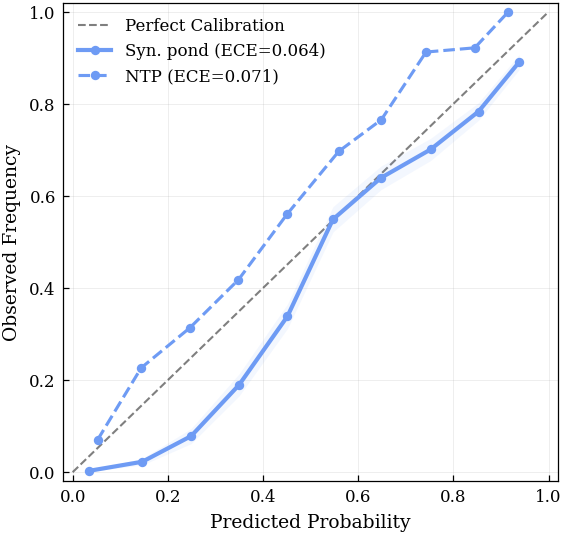

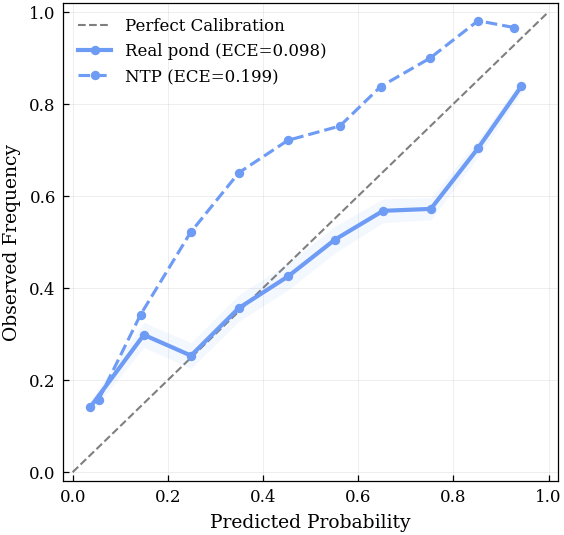

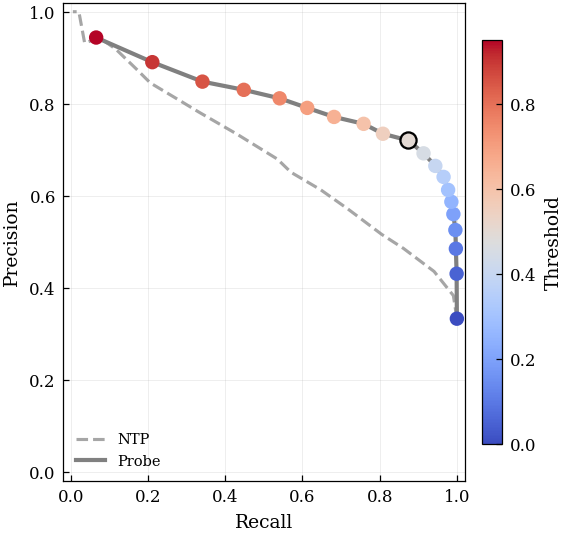

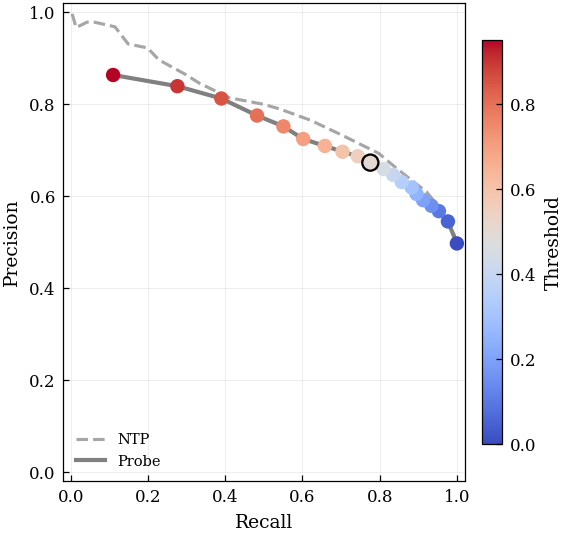

In [26]:
llama_results = analyze_probe('llama-3.1-8b', 'pond')


  llama-3.1-8b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Real pond: n=4157, pos=2065 (49.7%), pi_tr=0.333, pi_te_em=0.892, pi_te_act=0.497  [excl 6794 rows / 46 syn papers]

Summary — llama-3.1-8b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.746      0.782   0.331 0.465  0.810 0.071
   Syn. pond Probe     0.847      0.772   0.769 0.771  0.923 0.039
   Real pond   NTP     0.638      0.844   0.334 0.478  0.799 0.199
   Real pond Probe     0.690      0.646   0.831 0.727  0.787 0.128



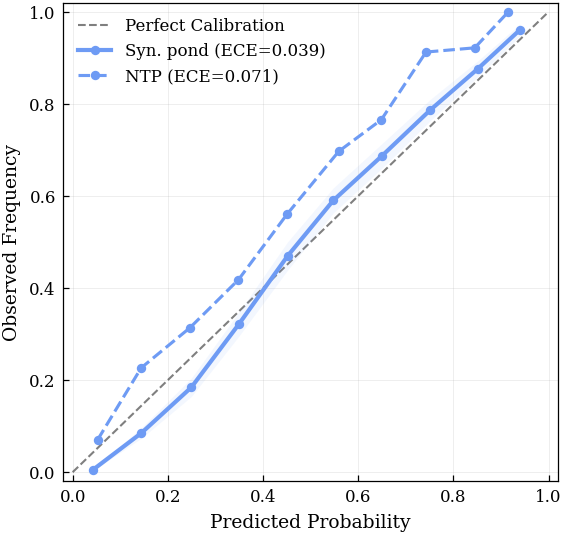

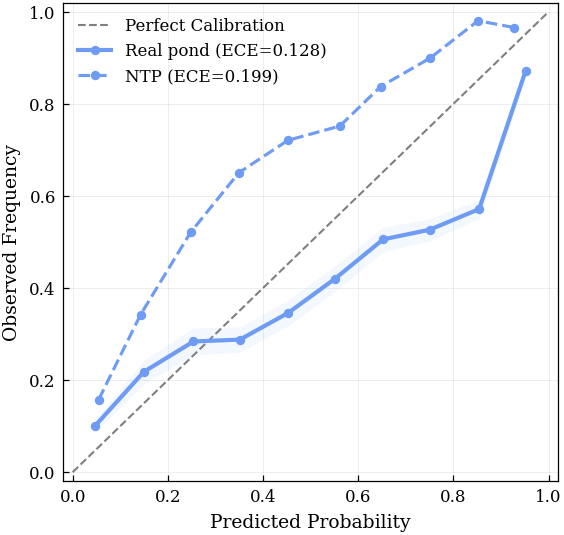

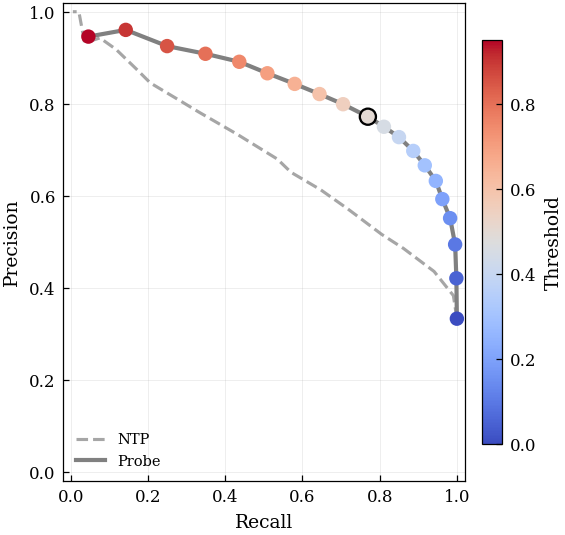

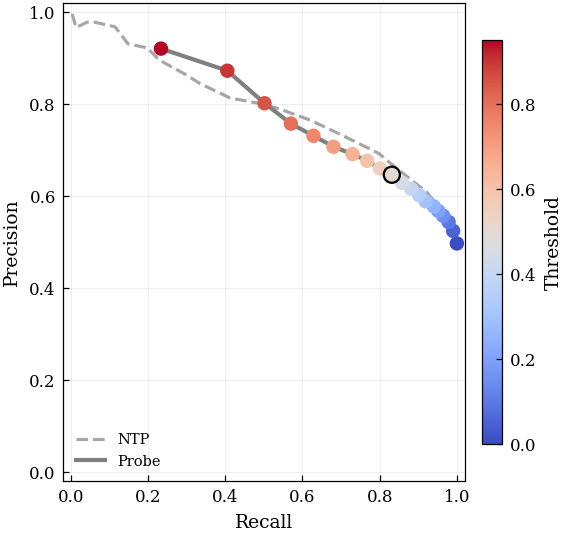

In [32]:
llama_results = analyze_probe('llama-3.1-8b', 'pond')


  llama-3.1-8b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Real pond: n=4157, pos=2065 (49.7%), pi_tr=0.333, pi_te_em=0.846, pi_te_act=0.497  [excl 6794 rows / 46 syn papers]

Summary — llama-3.1-8b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.746      0.782   0.331 0.465  0.810 0.071
   Syn. pond Probe     0.778      0.665   0.675 0.670  0.856 0.043
   Real pond   NTP     0.638      0.844   0.334 0.478  0.799 0.199
   Real pond Probe     0.689      0.658   0.778 0.713  0.769 0.105



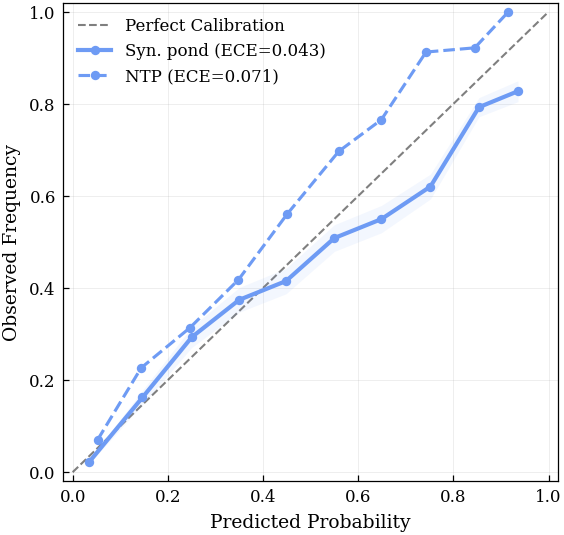

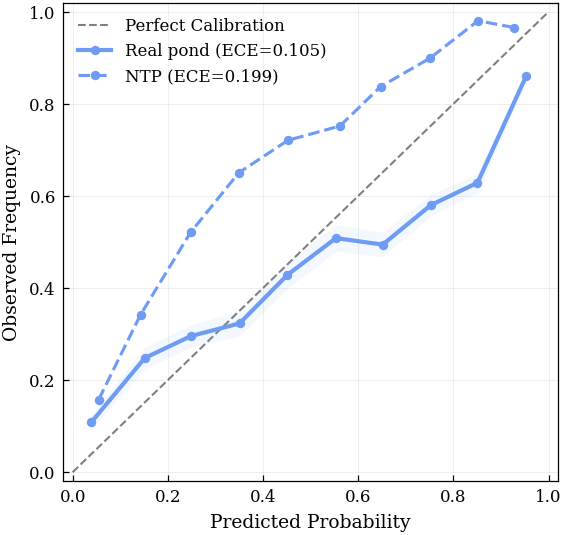

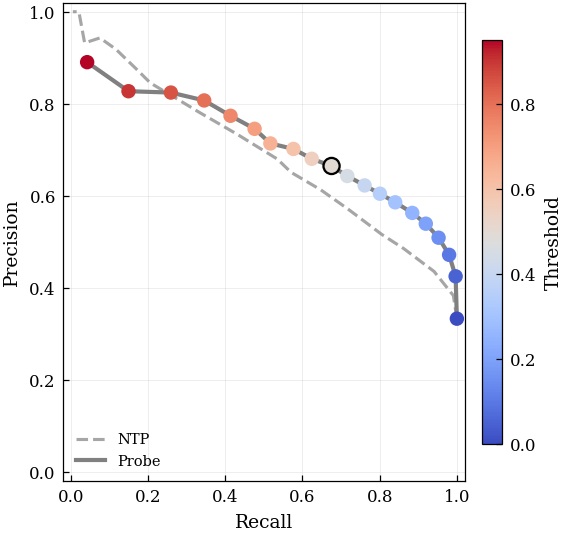

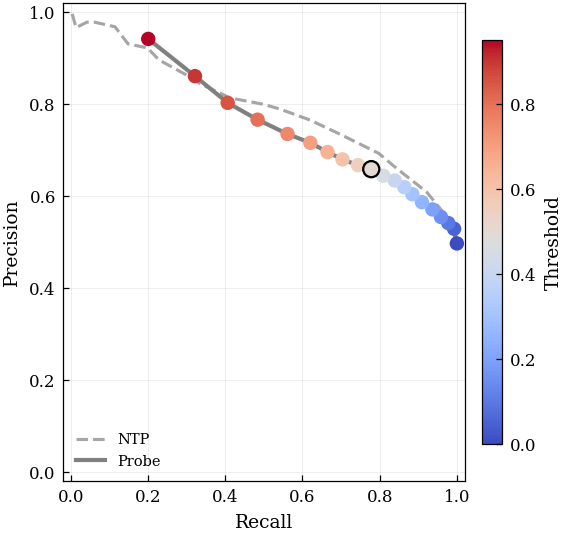

In [28]:
llama_results = analyze_probe('llama-3.1-8b', 'pond')


  mistral-7b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Real pond: n=4157, pos=2065 (49.7%), pi_tr=0.333, pi_te_em=0.581, pi_te_act=0.497  [excl 6794 rows / 46 syn papers]

Summary — mistral-7b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.520      0.407   0.965 0.573  0.712 0.447
   Syn. pond Probe     0.824      0.737   0.736 0.736  0.899 0.049
   Real pond   NTP     0.681      0.615   0.960 0.749  0.743 0.281
   Real pond Probe     0.620      0.669   0.464 0.548  0.708 0.136



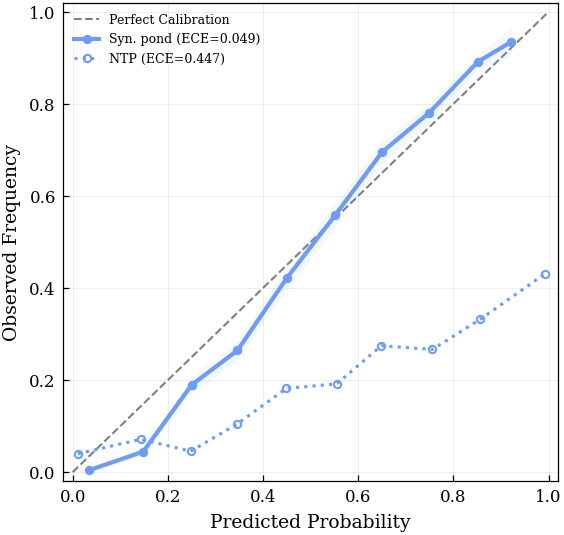

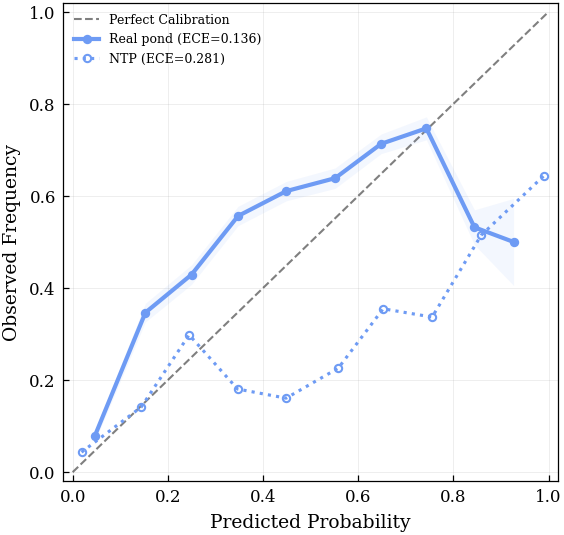

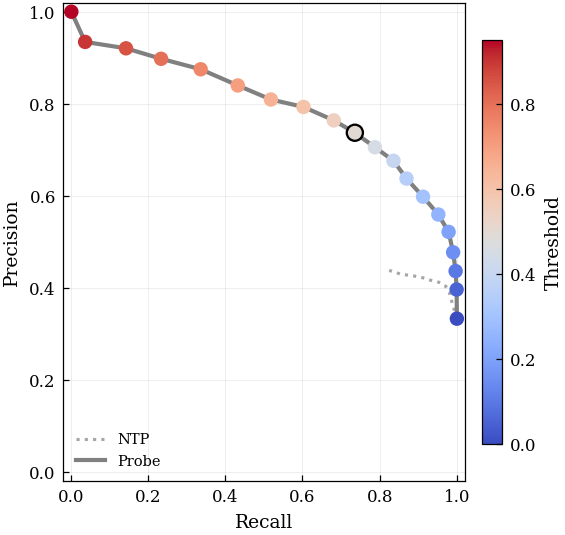

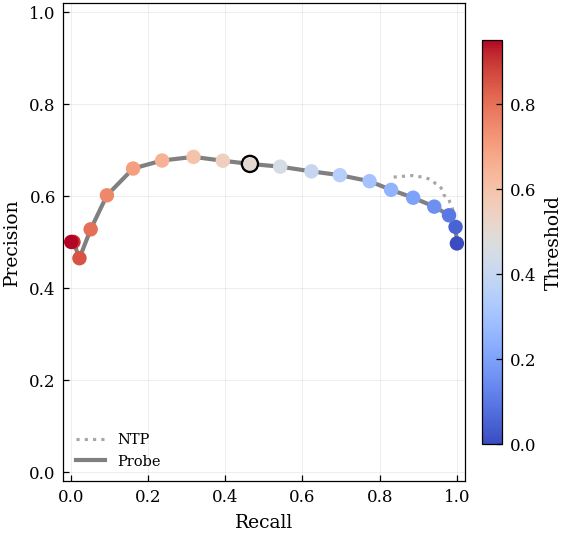

In [18]:
llama_results = analyze_probe('mistral-7b', 'pond')


  qwen-2.5-7b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Real pond: n=4157, pos=2065 (49.7%), pi_tr=0.333, pi_te_em=0.842, pi_te_act=0.497  [excl 6794 rows / 46 syn papers]

Summary — qwen-2.5-7b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.798      0.784   0.543 0.641  0.874 0.177
   Syn. pond Probe     0.862      0.779   0.820 0.799  0.927 0.028
   Real pond   NTP     0.739      0.796   0.638 0.708  0.837 0.225
   Real pond Probe     0.728      0.680   0.857 0.758  0.804 0.102



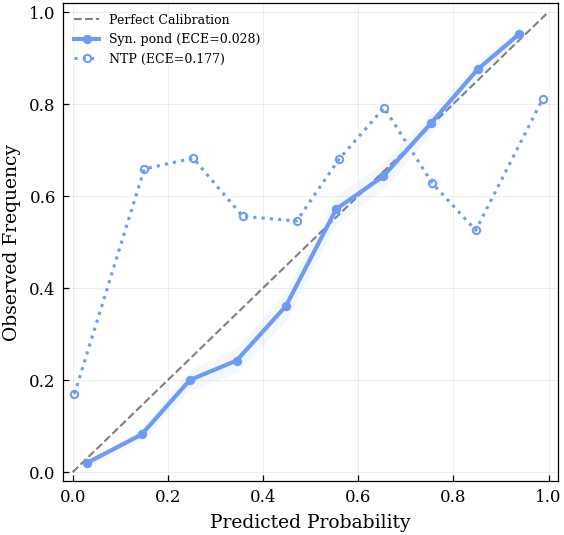

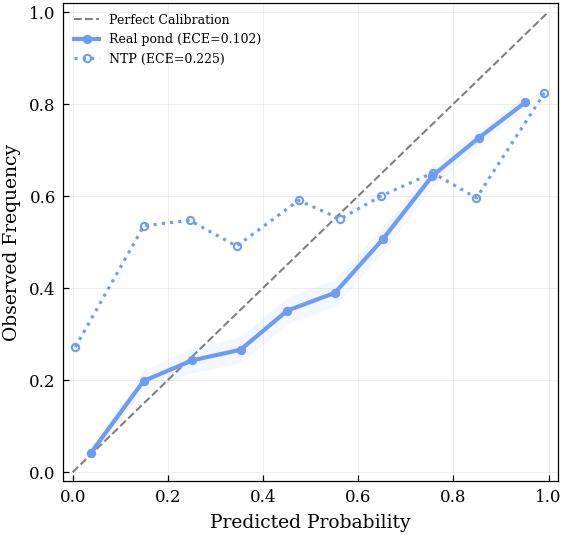

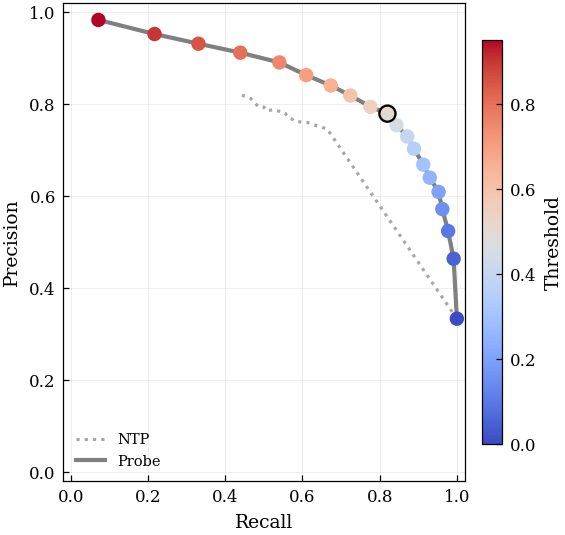

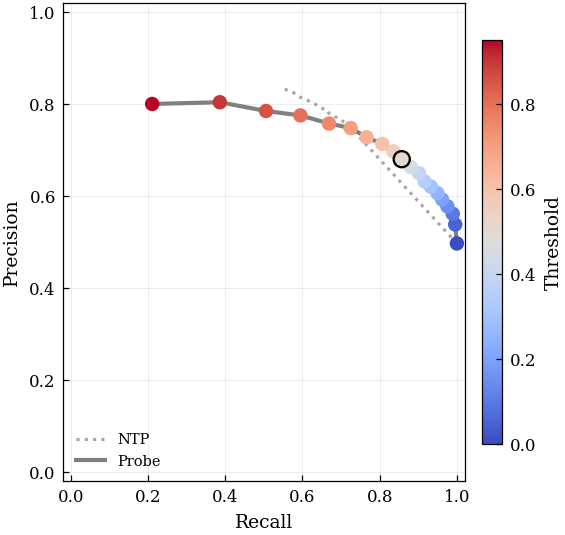

In [19]:
llama_results = analyze_probe('qwen-2.5-7b', 'pond')


  llama-3.1-8b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Syn. nfix: n=1347, pos=449 (33.3%)
  Real pond: n=4157, pos=2065 (49.7%), pi_tr=0.333, pi_te_em=0.905, pi_te_act=0.497  [excl 6794 rows / 46 syn papers]
  Real nfix: n=5832, pos=1472 (25.2%), pi_tr=0.333, pi_te_em=1.000, pi_te_act=0.252  [excl 0 rows / 0 syn papers]


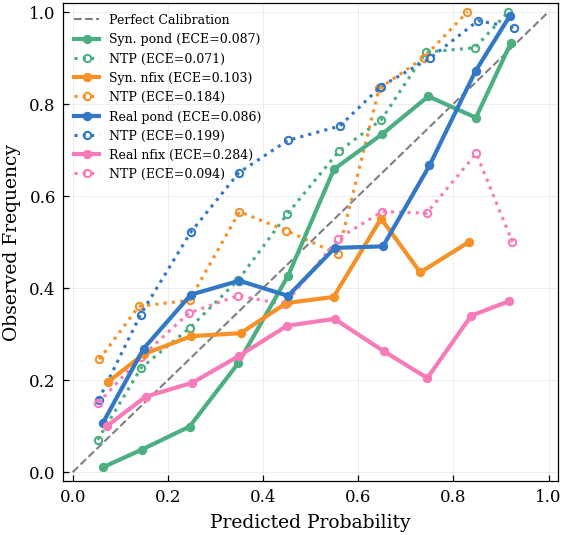

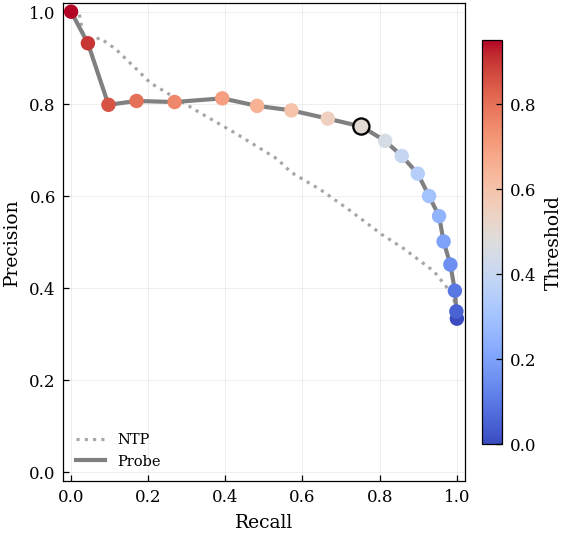

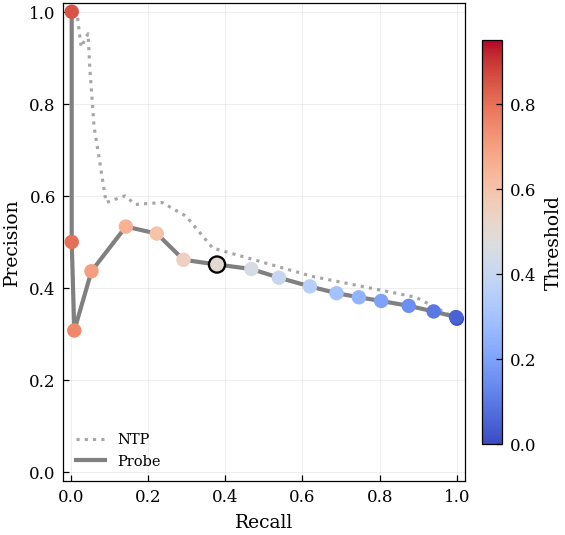

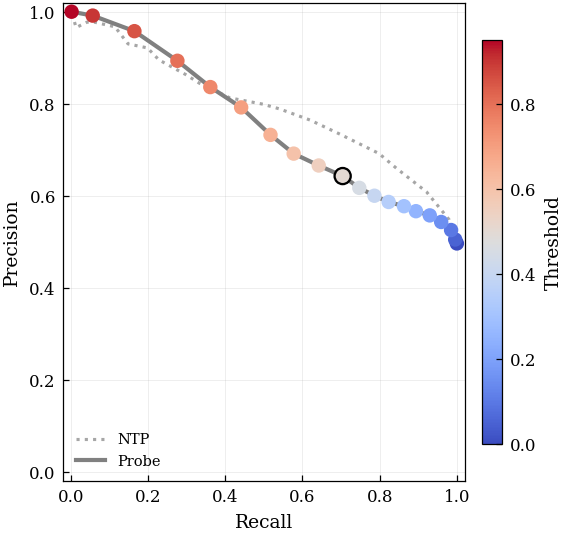

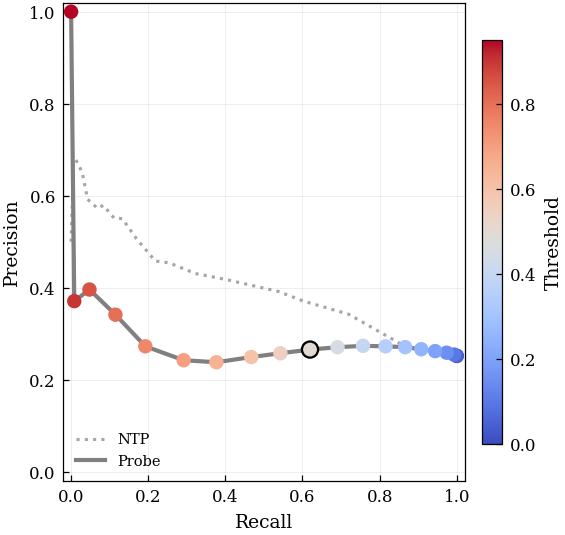


Summary — llama-3.1-8b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.746      0.782   0.331 0.465  0.810 0.071
   Syn. pond Probe     0.834      0.751   0.753 0.752  0.893 0.087
   Syn. nfix   NTP     0.680      0.705   0.069 0.126  0.656 0.184
   Syn. nfix Probe     0.639      0.451   0.379 0.412  0.617 0.103
   Real pond   NTP     0.638      0.844   0.334 0.478  0.799 0.199
   Real pond Probe     0.659      0.643   0.704 0.672  0.737 0.086
   Real nfix   NTP     0.754      0.550   0.132 0.213  0.659 0.094
   Real nfix Probe     0.473      0.266   0.620 0.372  0.530 0.284


  llama-3.1-8b  |  trained on nfix
  Syn. pond: n=4620, pos=1540 (33.3%)
  Syn. nfix: n=1347, pos=449 (33.3%)
  Real pond: n=10951, pos=5030 (45.9%), pi_tr=0.333, pi_te_em=0.667, pi_te_act=0.459  [excl 0 rows / 0 syn papers]
  Real nfix: n=3792, pos=666 (17.6%), pi_tr=0.333, pi_te_em=0.000, pi_te_act=0.176  [excl 2040 rows / 41 s

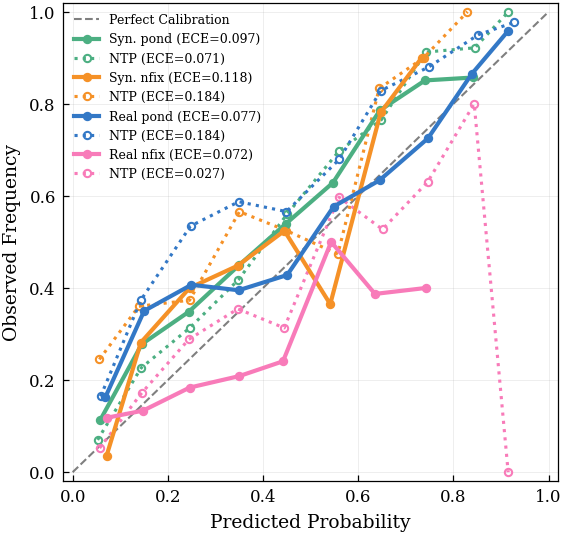

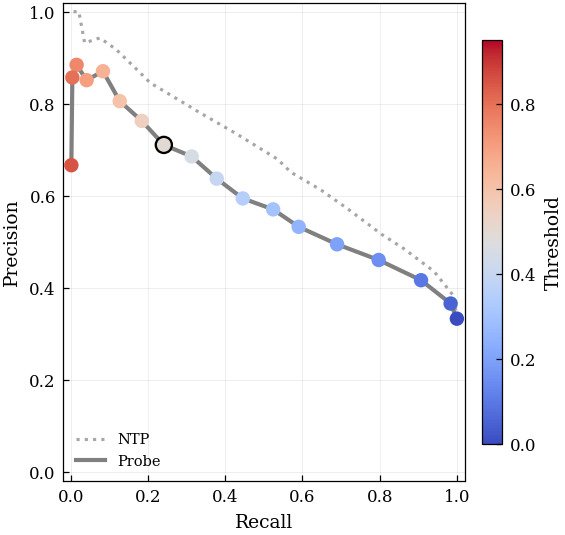

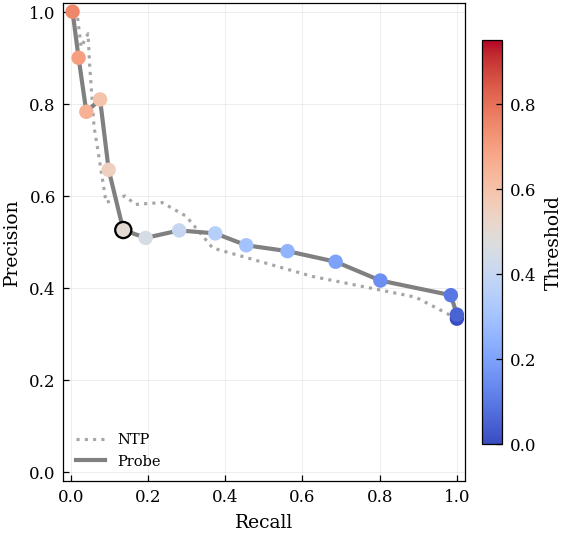

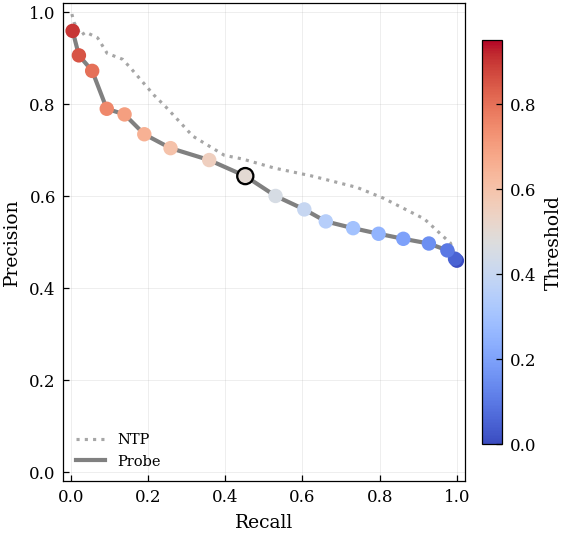

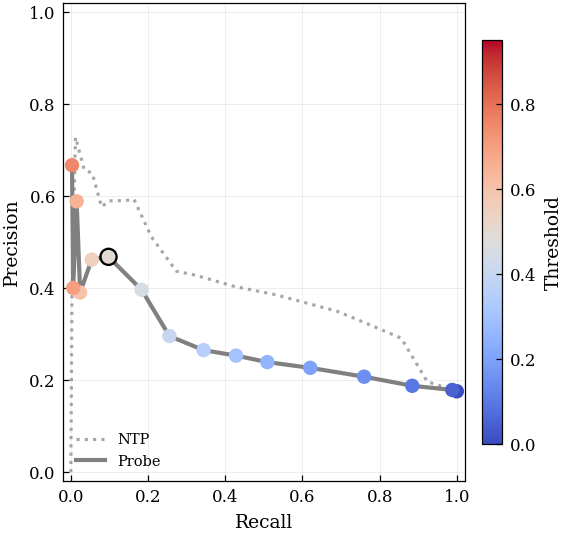


Summary — llama-3.1-8b  |  trained on nfix  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.746      0.782   0.331 0.465  0.810 0.071
   Syn. pond Probe     0.714      0.711   0.241 0.360  0.744 0.097
   Syn. nfix   NTP     0.680      0.705   0.069 0.126  0.656 0.184
   Syn. nfix Probe     0.671      0.526   0.136 0.216  0.694 0.118
   Real pond   NTP     0.624      0.792   0.247 0.377  0.739 0.184
   Real pond Probe     0.633      0.643   0.452 0.531  0.661 0.077
   Real nfix   NTP     0.833      0.588   0.161 0.252  0.759 0.027
   Real nfix Probe     0.822      0.468   0.098 0.161  0.613 0.072


  mistral-7b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Syn. nfix: n=1347, pos=449 (33.3%)
  Real pond: n=4157, pos=2065 (49.7%), pi_tr=0.333, pi_te_em=1.000, pi_te_act=0.497  [excl 6794 rows / 46 syn papers]
  Real nfix: n=5832, pos=1472 (25.2%), pi_tr=0.333, pi_te_em=0.418, pi_te_act=0.252  [excl 0 rows / 0 syn

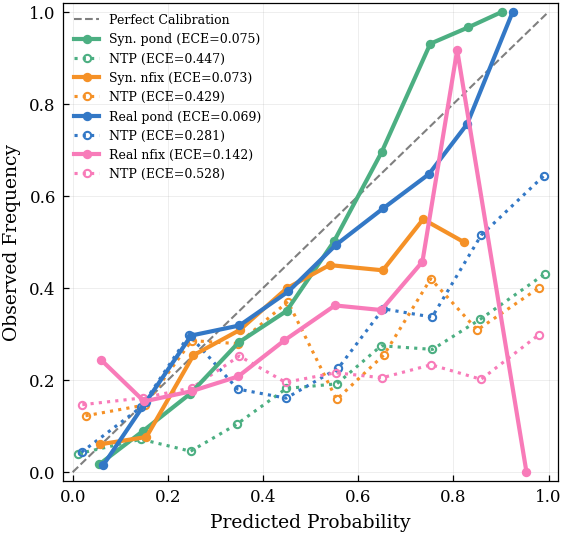

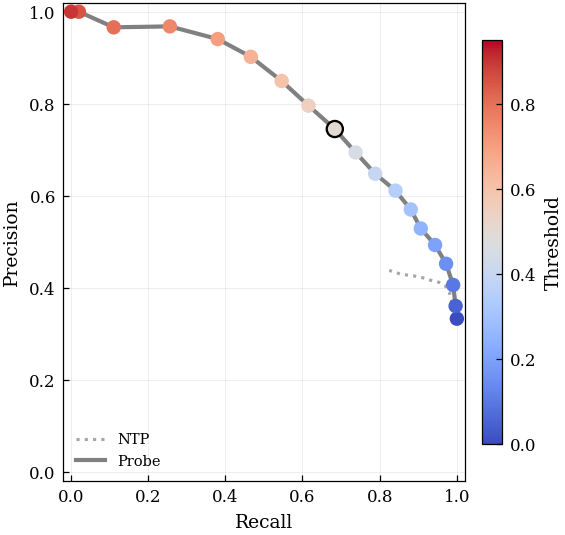

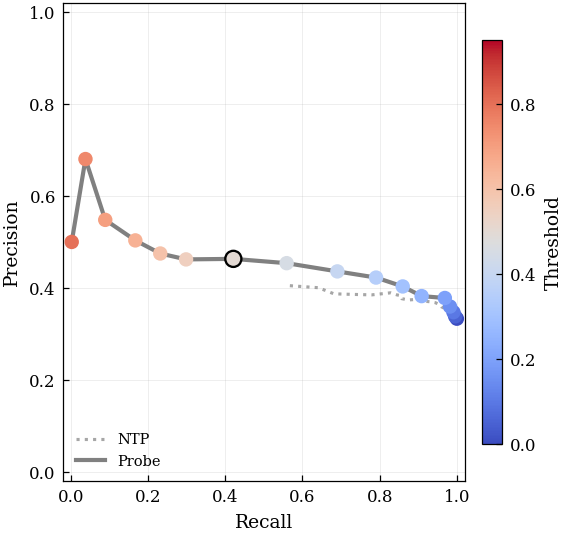

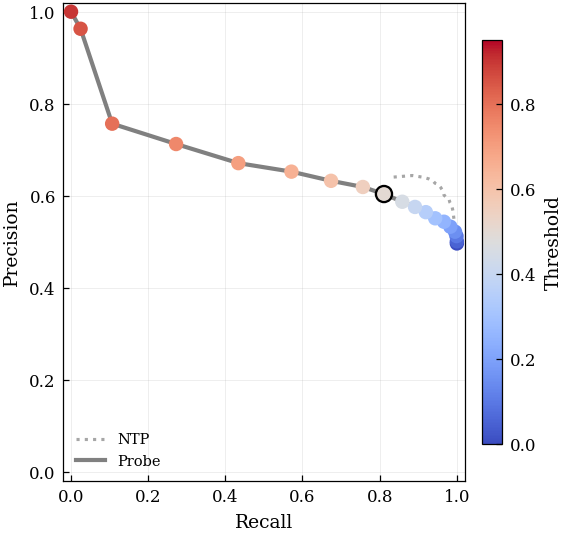

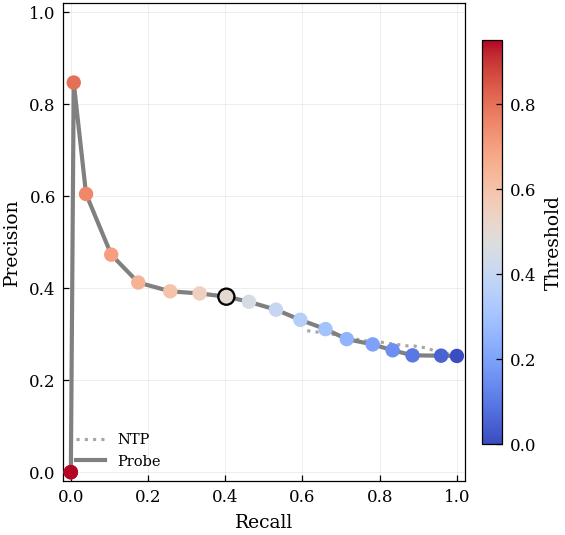


Summary — mistral-7b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.520      0.407   0.965 0.573  0.712 0.447
   Syn. pond Probe     0.817      0.745   0.684 0.713  0.881 0.075
   Syn. nfix   NTP     0.474      0.375   0.869 0.524  0.614 0.429
   Syn. nfix Probe     0.644      0.463   0.421 0.441  0.664 0.073
   Real pond   NTP     0.681      0.615   0.960 0.749  0.743 0.281
   Real pond Probe     0.642      0.604   0.811 0.692  0.700 0.069
   Real nfix   NTP     0.398      0.276   0.854 0.417  0.624 0.528
   Real nfix Probe     0.684      0.381   0.403 0.392  0.611 0.142


  mistral-7b  |  trained on nfix
  Syn. pond: n=4620, pos=1540 (33.3%)
  Syn. nfix: n=1347, pos=449 (33.3%)
  Real pond: n=10951, pos=5030 (45.9%), pi_tr=0.333, pi_te_em=0.942, pi_te_act=0.459  [excl 0 rows / 0 syn papers]
  Real nfix: n=3792, pos=666 (17.6%), pi_tr=0.333, pi_te_em=0.000, pi_te_act=0.176  [excl 2040 rows / 41 syn p

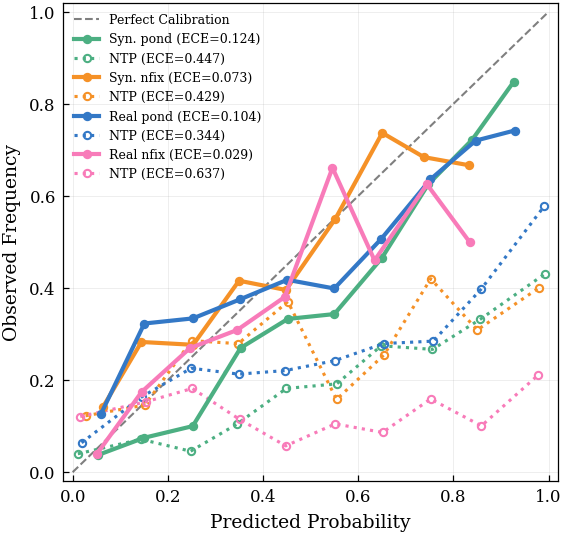

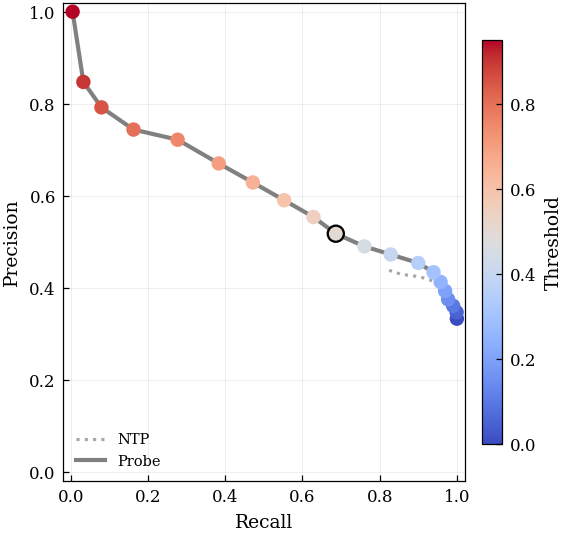

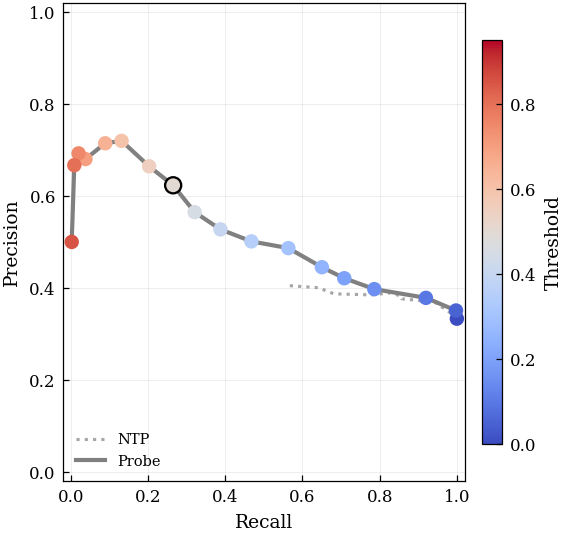

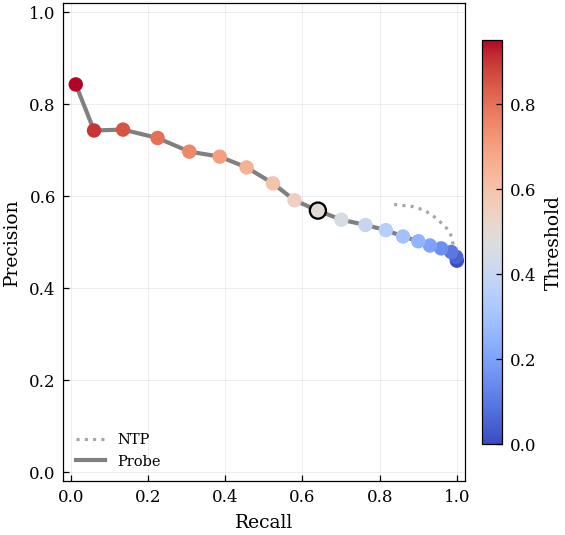

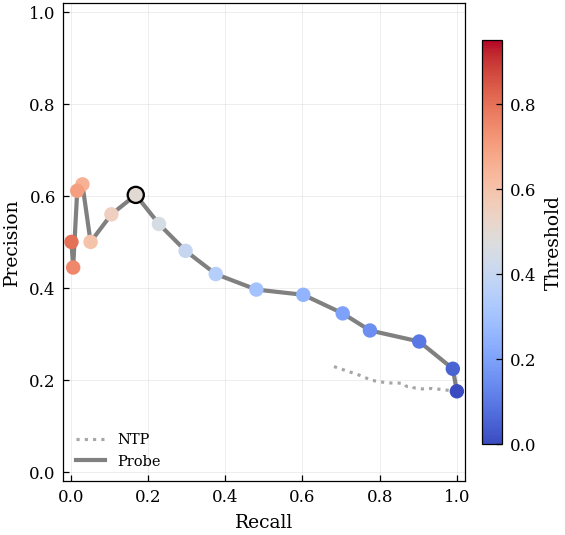


Summary — mistral-7b  |  trained on nfix  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.520      0.407   0.965 0.573  0.712 0.447
   Syn. pond Probe     0.682      0.518   0.686 0.590  0.768 0.124
   Syn. nfix   NTP     0.474      0.375   0.869 0.524  0.614 0.429
   Syn. nfix Probe     0.702      0.623   0.265 0.372  0.679 0.073
   Real pond   NTP     0.614      0.546   0.953 0.694  0.695 0.344
   Real pond Probe     0.611      0.568   0.640 0.602  0.672 0.104
   Real nfix   NTP     0.296      0.185   0.884 0.306  0.643 0.637
   Real nfix Probe     0.834      0.602   0.168 0.263  0.788 0.029


  qwen-2.5-7b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Syn. nfix: n=1347, pos=449 (33.3%)
  Real pond: n=4157, pos=2065 (49.7%), pi_tr=0.333, pi_te_em=0.878, pi_te_act=0.497  [excl 6794 rows / 46 syn papers]
  Real nfix: n=5832, pos=1472 (25.2%), pi_tr=0.333, pi_te_em=0.480, pi_te_act=0.252  [excl 0 rows / 0 syn 

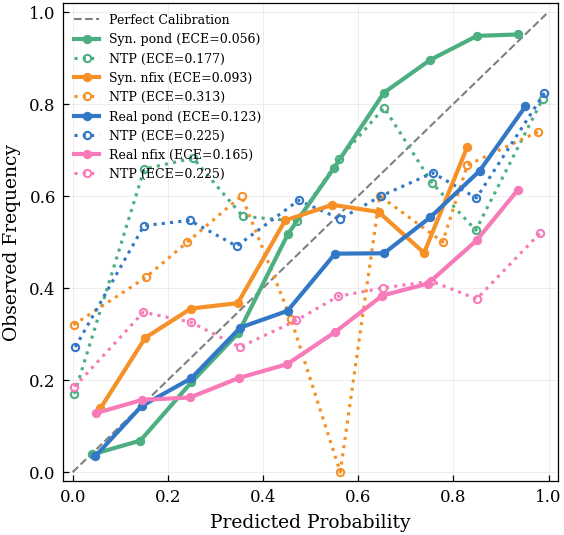

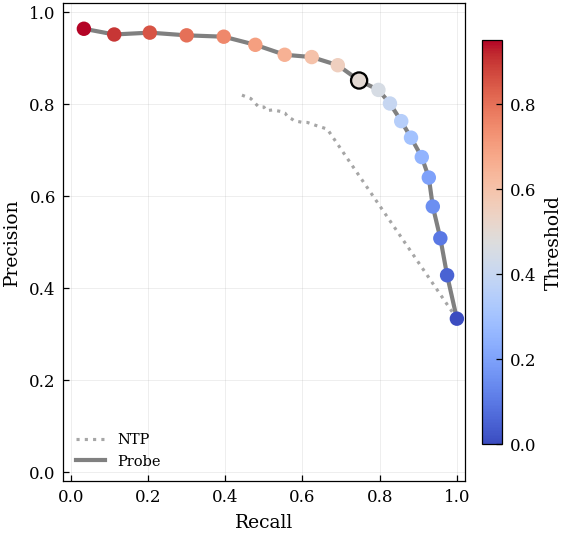

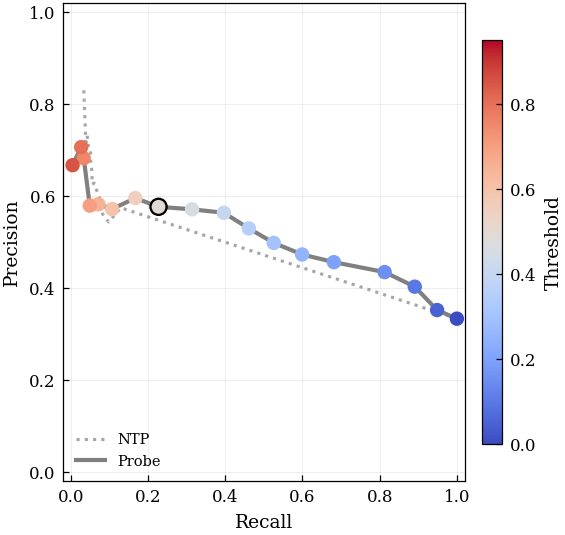

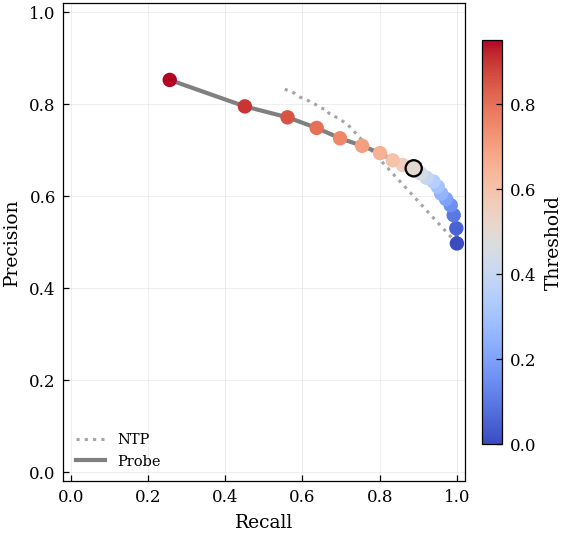

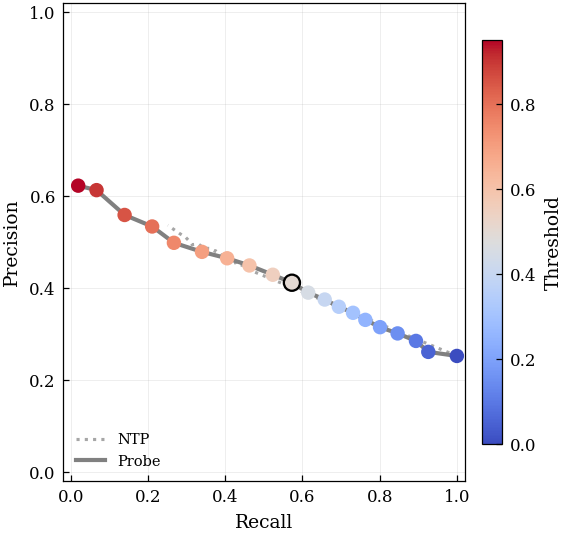


Summary — qwen-2.5-7b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.798      0.784   0.543 0.641  0.874 0.177
   Syn. pond Probe     0.872      0.851   0.747 0.795  0.922 0.056
   Syn. nfix   NTP     0.676      0.676   0.051 0.095  0.645 0.313
   Syn. nfix Probe     0.687      0.576   0.227 0.326  0.694 0.093
   Real pond   NTP     0.739      0.796   0.638 0.708  0.837 0.225
   Real pond Probe     0.717      0.660   0.888 0.757  0.803 0.123
   Real nfix   NTP     0.740      0.480   0.373 0.420  0.722 0.225
   Real nfix Probe     0.685      0.411   0.573 0.479  0.683 0.165


  qwen-2.5-7b  |  trained on nfix
  Syn. pond: n=4620, pos=1540 (33.3%)
  Syn. nfix: n=1347, pos=449 (33.3%)
  Real pond: n=10951, pos=5030 (45.9%), pi_tr=0.333, pi_te_em=0.366, pi_te_act=0.459  [excl 0 rows / 0 syn papers]
  Real nfix: n=3792, pos=666 (17.6%), pi_tr=0.333, pi_te_em=0.541, pi_te_act=0.176  [excl 2040 rows / 41 syn

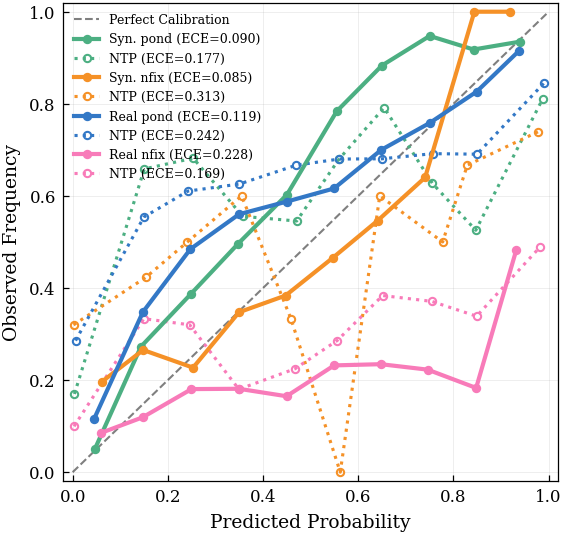

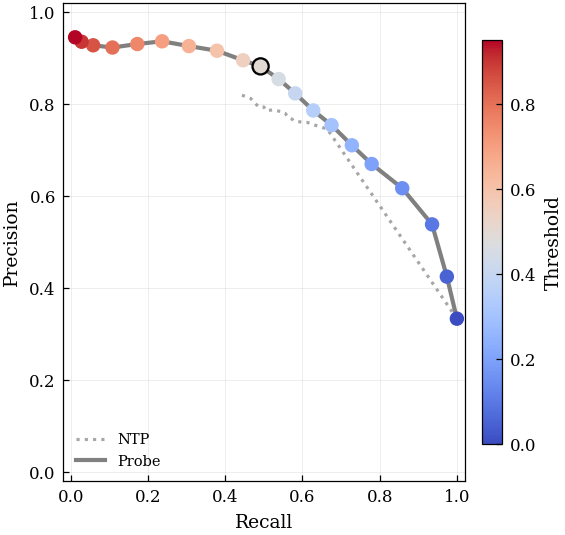

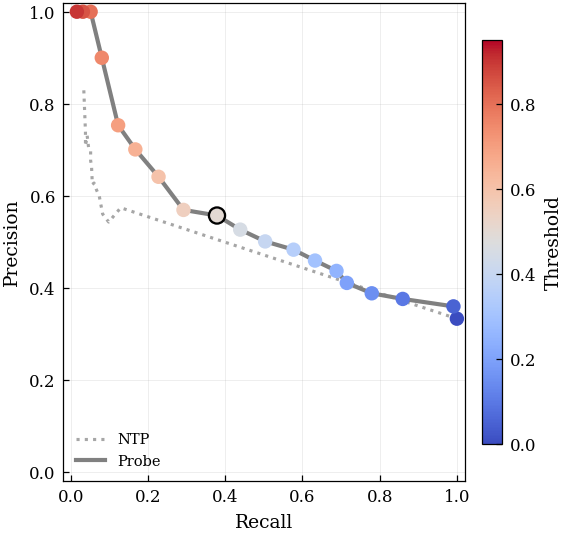

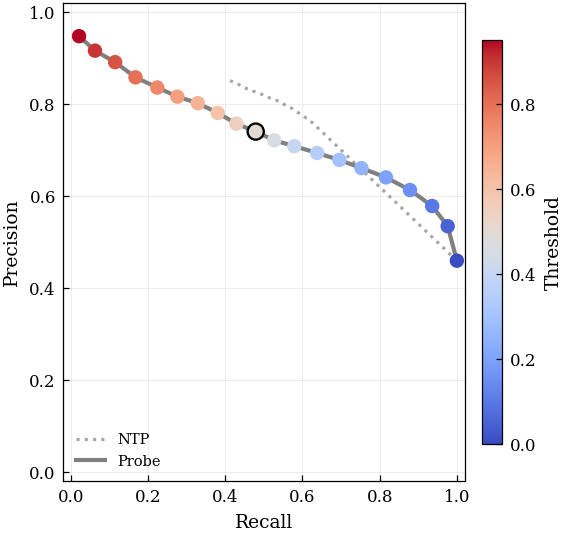

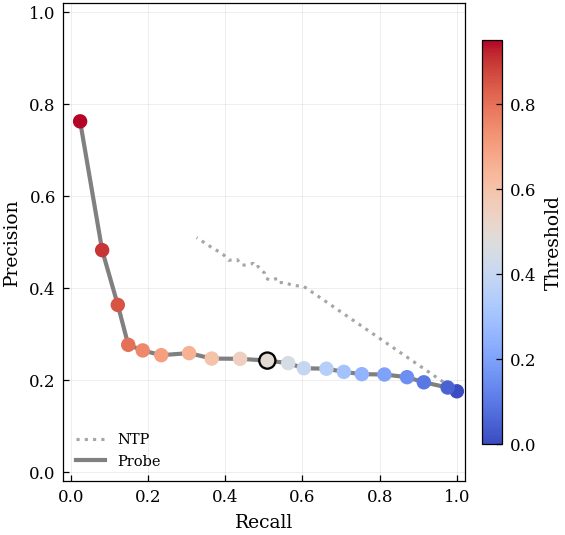


Summary — qwen-2.5-7b  |  trained on nfix  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.798      0.784   0.543 0.641  0.874 0.177
   Syn. pond Probe     0.808      0.881   0.492 0.631  0.883 0.090
   Syn. nfix   NTP     0.676      0.676   0.051 0.095  0.645 0.313
   Syn. nfix Probe     0.693      0.557   0.379 0.451  0.677 0.085
   Real pond   NTP     0.721      0.815   0.509 0.627  0.818 0.242
   Real pond Probe     0.683      0.740   0.479 0.581  0.788 0.119
   Real nfix   NTP     0.803      0.444   0.480 0.462  0.788 0.169
   Real nfix Probe     0.634      0.242   0.509 0.328  0.624 0.228



In [13]:
all_results = {}
for jm in JUDGE_MODELS:
    for train_ds in DATASETS:
        all_results[(jm, train_ds)] = analyze_probe(jm, train_ds)

---
# Code testing

In [40]:
judge_model = 'llama-3.1-8b'
train_dataset = 'pond'

"""Calibration curves, threshold sweep, and metrics table for one
(judge_model, train_dataset) pair evaluated across four test settings."""
pd_data  = probe_cache[train_dataset][judge_model]
top_k    = pd_data['top_k_heads']
header   = f'{judge_model}  |  trained on {train_dataset}'
SEP      = '=' * 72
print(f'\n{SEP}\n  {header}\n{SEP}')

# ── Collect data for each test setting ────────────────────────────────
setting_results = []

for dtype in ('syn', 'real'):
    for test_ds in DATASETS:
        dtype_str = 'Syn.' if dtype == 'syn' else 'Real'
        s_label  = f'{dtype_str} {test_ds}'
        color    = _DS_COLORS[test_ds]
        ls       = _DTYPE_LS[dtype]

        if dtype == 'syn':
            jdate    = JUDGE_DATES_SYN[test_ds][judge_model]
            syn_act  = load_synthetic_activations(test_ds, judge_model, jdate, split='test')
            syn_resp = load_synthetic_responses(test_ds, judge_model, jdate, split='test')
            syn_df_s = pd.DataFrame(syn_resp)
            mids     = syn_df_s['measurement_id'].tolist()
            labels   = (syn_df_s['label'] == 'valid').to_numpy(dtype=bool)

            X = np.concatenate([
                np.stack([
                    np.array(syn_act[str(mid)], dtype=np.float32)[l, h, :]
                    for mid in mids
                ], axis=0)
                for l, h in top_k
            ], axis=1)
            raw_probs = pd_data['probe'].predict_proba(X)[:, 1]
            ntp_probs = syn_df_s['judgement_p_true'].to_numpy()

            print(f'  {s_label}: n={len(mids)}, pos={labels.sum()} '
                  f'({labels.mean():.1%})')
            setting_results.append({
                'label': s_label, 'color': color, 'ls': ls,
                'probe_probs': raw_probs, 'ntp_probs': ntp_probs,
                'labels': labels, 'is_syn': True,
            })

        else:  # real
            td       = test_data[test_ds]
            real_df  = td['real_df']
            syn_docs = set(pd_data['syn_document_ids'])
            mask     = ~real_df['document_id'].isin(syn_docs)
            idx      = np.where(mask.to_numpy())[0]
            mids     = real_df['measurement_id'].iloc[idx].tolist()
            labels   = td['real_labels'][idx]

            jdate    = JUDGE_DATES_REAL[test_ds][judge_model]
            real_act = load_activations(
                test_ds, EXTRACTION_MODEL, EXTRACTION_DATES[test_ds], judge_model, jdate
            )
            X = np.concatenate([
                np.stack([
                    np.array(real_act[str(mid)], dtype=np.float32)[l, h, :]
                    for mid in mids
                ], axis=0)
                for l, h in top_k
            ], axis=1)
            raw_probs = pd_data['probe'].predict_proba(X)[:, 1]

            # Assuming label shift from synthetic train setting -> real test setting, 
            # rescale the probabilities using an EM algorithm. 
            cal_probs, pi_te = rescale_probabilities_em(
                raw_probs, pi_tr=pd_data['train_prevalence']
            )

            pi_te_act = np.mean(labels)
            pi_te = pi_te_act
            pi_tr = pd_data['train_prevalence']
            num = raw_probs * (pi_te / pi_tr)
            den = num + (1 - raw_probs) * ((1 - pi_te) / (1 - pi_tr))
            cal_probs = num / den
            
            ntp_probs = real_df[f'judgement_p_true_{judge_model}'].iloc[idx].to_numpy()

            n_gt = len(td['ground_truth_df'])
            ex_to_test_pos = {int(idx[i]): i for i in range(len(idx))}
            test_edges = [
                (int(gt_i), ex_to_test_pos[int(ex_i)])
                for (gt_i, ex_i), w in zip(td['edges'], td['edge_weights'])
                if int(ex_i) in ex_to_test_pos and w > EDGE_THRESHOLD
            ]
            n_excl = int((~mask).sum())
            n_pap  = real_df.loc[~mask, 'document_id'].nunique()
            print(f'  {s_label}: n={len(idx)}, pos={labels.sum()} '
                  f'({labels.mean():.1%}), pi_tr={pd_data['train_prevalence']:.3f}, pi_te_em={pi_te:.3f}, pi_te_act={np.mean(labels):.3f}  '
                  f'[excl {n_excl} rows / {n_pap} syn papers]')
            setting_results.append({
                'label': s_label, 'color': color, 'ls': ls,
                'probe_probs': cal_probs, 'ntp_probs': ntp_probs,
                'labels': labels, 'is_syn': False,
                'test_edges': test_edges, 'n_gt': n_gt,
            })


  llama-3.1-8b  |  trained on pond
  Syn. pond: n=4620, pos=1540 (33.3%)
  Real pond: n=2551, pos=2180 (85.5%), pi_tr=0.333, pi_te_em=0.855, pi_te_act=0.855  [excl 2412 rows / 48 syn papers]


In [83]:
# Updated color scheme: distinguish by (dataset, data_type)
_DS_COLORS_REFINED = {
    ('pond', 'syn'):  '#4CAF82',
    ('pond', 'real'): "#3378C6",
    ('nfix', 'syn'):  "#F59127",
    ('nfix', 'real'): "#F87BB9",
}
_DTYPE_LS = {'real': '-', 'syn': '-'}

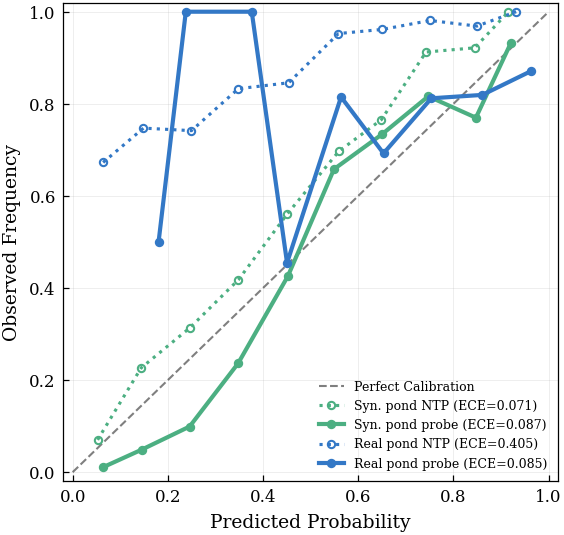

In [84]:
# ── Figure 1: Calibration curves ──────────────────────────────────────
fig_cal, ax_cal = plt.subplots(figsize=(4.0, 3.8))
ax_cal.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.5, label='Perfect Calibration', zorder=1)

for r in setting_results:
    # Determine color based on dataset and dtype
    test_ds = 'pond' if 'pond' in r['label'].lower() else 'nfix'
    dtype = 'syn' if r['is_syn'] else 'real'
    color = _DS_COLORS_REFINED[(test_ds, dtype)]

    # NTP baseline — very faint, dashed
    d_ntp = reliability_diagram_data(r['ntp_probs'], r['labels'])
    v_ntp = d_ntp['bin_counts'] > 0
    ax_cal.plot(
        d_ntp['bin_confidence'][v_ntp], d_ntp['bin_accuracy'][v_ntp],
        ':', color=color, lw=1.5, alpha=1.0, zorder=1, marker='o', ms=3.5, markerfacecolor='none',
        label=f"{r['label']} NTP (ECE={d_ntp['ece']:.3f})",
    )

    # Probe — solid line with markers
    d_prb = reliability_diagram_data(r['probe_probs'], r['labels'])
    v_prb = d_prb['bin_counts'] > 0
    ax_cal.plot(
        d_prb['bin_confidence'][v_prb], d_prb['bin_accuracy'][v_prb],
        r['ls'], color=color, lw=2.0, marker='o', ms=3.5,
        label=f"{r['label']} probe (ECE={d_prb['ece']:.3f})",
        zorder=3,
    )
    
    # Add error bands: SEM of accuracy within each bin (very subtle)
    '''
    bin_sems = d_prb['bin_accuracy_sem'][v_prb]
    conf_valid = d_prb['bin_confidence'][v_prb]
    acc_valid = d_prb['bin_accuracy'][v_prb]
    
    ax_cal.fill_between(
        conf_valid, 
        acc_valid - bin_sems, 
        acc_valid + bin_sems,
        color=color, alpha=0.08, linewidth=0, zorder=2
    )
    '''

ax_cal.set_xlim(-0.02, 1.02)
ax_cal.set_ylim(-0.02, 1.02)
ax_cal.set_xlabel('Predicted Probability', fontsize=9)
ax_cal.set_ylabel('Observed Frequency', fontsize=9)
ax_cal.legend(fontsize=6, loc='best', handlelength=2.0, framealpha=0.95)
ax_cal.grid(alpha=0.25, linestyle='-', linewidth=0.4)
ax_cal.set_axisbelow(True)
fig_cal.tight_layout()
plt.show()
# fig_cal.savefig(
#     FIGURES_DIR + f'cal_{judge_model}_{train_dataset}.pdf', bbox_inches='tight',
# )

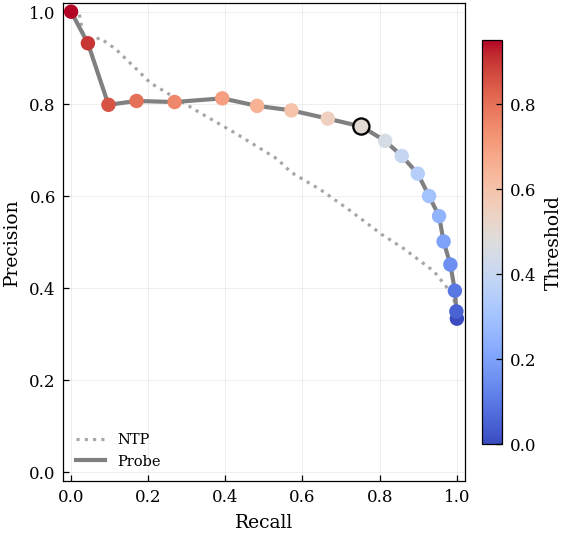

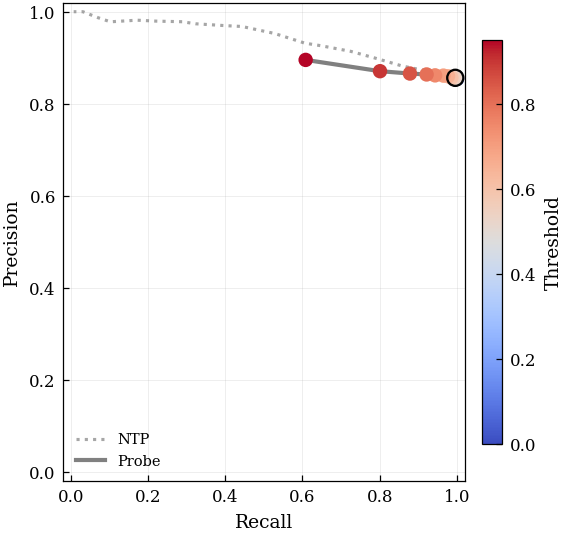

In [96]:
    # ── Figure 2: Precision-Recall curves (separate plots) ──────────────────
    for r in setting_results:
        fig_pr, ax_pr = plt.subplots(figsize=(4.0, 3.8))
        
        probe_prec, probe_rec = [], []
        ntp_prec,   ntp_rec   = [], []
        
        for t in THRESHOLD_SWEEP:
            # Compute precision and recall for probe
            preds_prb = r['probe_probs'] > t
            y_true = r['labels'].astype(bool)
            tp_prb = int((preds_prb & y_true).sum())
            fp_prb = int((preds_prb & ~y_true).sum())
            fn_prb = int((~preds_prb & y_true).sum())
            
            prec_prb = tp_prb / (tp_prb + fp_prb) if (tp_prb + fp_prb) > 0 else float('nan')
            rec_prb = tp_prb / (tp_prb + fn_prb) if (tp_prb + fn_prb) > 0 else float('nan')
            probe_prec.append(prec_prb)
            probe_rec.append(rec_prb)
            
            # Compute precision and recall for NTP
            preds_ntp = r['ntp_probs'] > t
            tp_ntp = int((preds_ntp & y_true).sum())
            fp_ntp = int((preds_ntp & ~y_true).sum())
            fn_ntp = int((~preds_ntp & y_true).sum())
            
            prec_ntp = tp_ntp / (tp_ntp + fp_ntp) if (tp_ntp + fp_ntp) > 0 else float('nan')
            rec_ntp = tp_ntp / (tp_ntp + fn_ntp) if (tp_ntp + fn_ntp) > 0 else float('nan')
            ntp_prec.append(prec_ntp)
            ntp_rec.append(rec_ntp)

        pr_prec = np.array(probe_prec);  pr_rec = np.array(probe_rec)
        nt_prec = np.array(ntp_prec);    nt_rec = np.array(ntp_rec)
        v_pr = ~(np.isnan(pr_prec) | np.isnan(pr_rec))
        v_nt = ~(np.isnan(nt_prec) | np.isnan(nt_rec))

        cmap = cm.coolwarm
        norm = mcolors.Normalize(vmin=THRESHOLD_SWEEP.min(), vmax=THRESHOLD_SWEEP.max())
        sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        # NTP — faint dotted line
        if v_nt.any():
            ax_pr.plot(nt_rec[v_nt], nt_prec[v_nt], ':', color='#888888',
                       lw=1.5, alpha=0.75, zorder=2, label='NTP')

        # Probe — solid line with colored scatter points by threshold
        if v_pr.any():
            ax_pr.plot(pr_rec[v_pr], pr_prec[v_pr], '-', color='grey',
                       lw=2.0, zorder=3, label='Probe')
            ax_pr.scatter(pr_rec[v_pr], pr_prec[v_pr], c=THRESHOLD_SWEEP[v_pr],
                          cmap=cmap, norm=norm, s=35, zorder=3)

        # Mark threshold = 0.5
        idx0 = np.argmin(np.abs(THRESHOLD_SWEEP - 0.5))
        if v_pr[idx0]:
            ax_pr.scatter([pr_rec[idx0]], [pr_prec[idx0]], s=60, c='none',
                          edgecolors='k', linewidths=1.1, zorder=4, marker='o')

        ax_pr.set_xlim(-0.02, 1.02)
        ax_pr.set_ylim(-0.02, 1.02)
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.legend(fontsize=7, loc='lower left')
        ax_pr.grid(alpha=0.25, linestyle='-', linewidth=0.4)
        ax_pr.set_axisbelow(True)

        fig_pr.colorbar(sm, ax=ax_pr, label='Threshold',
                        fraction=0.046, pad=0.04)
        fig_pr.tight_layout()
        # fig_pr.savefig(
        #     FIGURES_DIR + f'pr_{judge_model}_{train_dataset}_{r["label"].replace(" ", "_")}.pdf',
        #     bbox_inches='tight',
        # )
        plt.show()

In [86]:
rows = []
for r in setting_results:
    for probs, kind in [(r['ntp_probs'], 'NTP'), (r['probe_probs'], 'Probe')]:
        m = _probe_metrics(probs, r['labels'])
        rows.append({
            'Test setting':  r['label'],
            'Type':          kind,
            'Accuracy':      m['acc'],
            'Precision':     m['prec'],
            'Recall':        m['rec'],
            'F1':            m['f1'],
            'AUROC':         m['auroc'],
            'ECE':           m['ece'],
        })

df = pd.DataFrame(rows)
print(f'\nSummary — {header}  (threshold = 0.5):')
print(df.to_string(index=False, float_format='{:.3f}'.format))
print()


Summary — llama-3.1-8b  |  trained on pond  (threshold = 0.5):
Test setting  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
   Syn. pond   NTP     0.746      0.782   0.331 0.465  0.810 0.071
   Syn. pond Probe     0.834      0.751   0.753 0.752  0.893 0.087
   Real pond   NTP     0.512      0.969   0.443 0.608  0.733 0.405
   Real pond Probe     0.854      0.856   0.996 0.921  0.645 0.085

